# 07 — Per-sensor track crossings: the calorimeter step-truth route


> **Route 2 of 2 for building the sensor crossings — the calorimeter route, an independent**
> **cross-check of [06](06_sensor_crossings_tracker.ipynb) with complementary strengths.** With `enableDetailedShowerMode`,
> every Geant4 step deposit becomes a `CaloHitContribution` (global position + energy + time +
> producing-particle link); crossings are reconstructed by **time-ordering** the steps of each
> (particle, sensor) and splitting them into per-layer runs. This route gives what 06 cannot —
> an entry-**anchored** position (the earliest-in-time step; caveat: for single-step
> crossings — about 2/3 here — the recorded step position is its midpoint, ~mid-sensor) and the
> full **step-level deposit** inside the sensor — at the cost of momentum: the
> `CaloHitContribution` schema has none, so each crossing inherits the producing particle's
> *production* momentum (fine for the hard, near-straight tracks that dominate; wrong for a
> particle that has radiated to low energy by a deep layer).

The same silicon can be read out two ways, and CALOMAPS uses **both**:

| | Calorimeter readout (this notebook, 07) | Tracker readout ([06](06_sensor_crossings_tracker.ipynb)) |
|---|---|---|
| EDM4hep object | `SimCalorimeterHit` + `CaloHitContribution` | `SimTrackerHit` |
| Position | **entry-anchored** + every step inside the sensor | energy-weighted (≈ mid-plane) |
| Momentum | production only (no per-step) | **real per-crossing momentum** |
| Step-level deposit | **yes** (per-step dE) | combined per crossing |
| Builder variant | **A** (`build_segments_A`) | C (`build_segments_C`) |
| Use when | only a calo readout exists; entry / step detail needed | the βγ / dE/dx regime matters |

The sensitive detector is a passive observer — it changes only *what is recorded*, not the
physics; the calorimeter and tracker runs use the same gun, physics list and seed, so the
shower is identical. See [**06 §2b**](06_sensor_crossings_tracker.ipynb) for the full
side-by-side, the born-outside vs born-inside (delta-ray) distinction, and what each readout
is for.


## 1. What a sensor-level simulation consumes — and why energy deposits are *not* it

A detailed silicon simulation (a charge-transport code such as PIXELAV) is **not** an
energy-deposit consumer. Given a charged track's geometry and kinematics it **generates the
ionization itself** — δ-rays included — then drifts, diffuses and traps the electron–hole
pairs through the sensor's electric and magnetic fields to produce the induced pixel signal.
The input is **track segments**, not the Geant4 energy deposits. A crossing record, in the
sensor's **local** frame, is:
- the **local impact point** `(u, v)` — `u` across the pixel pitch, `v` along the cylinder-z
  axis;
- the **direction slopes** `cot α = p_u/p_w`, `cot β = p_v/p_w`, where `w` is the
  sensor-normal (depth) axis;
- the **momentum magnitude** `|p|` (sets the βγ / dE/dx regime: a MIP vs a soft electron);
- the **particle type**.

Such a tool transports the straight track across the **full sensor depth itself**, so it
works from an *impact point + direction*, not a separately stored exit. **Why the whole-track
endpoints from notebook 05 are not enough:** an `MCParticle`'s `vertex`/`endpoint` bracket its
entire trajectory — birth to final stop, possibly several sensors and tungsten plates away.
Sensor-level simulation works **one sensor at a time**. The per-crossing geometry lives in the
per-step `CaloHitContribution` truth, which is what we surface and reshape here.

**Does the sensor simulation's result have to "match" Geant4? No — and that is the point.**
A charge-transport code does not produce an outgoing particle to compare against Geant4 — it
produces the **induced pixel charge cluster** (the detector's electrical response). The two
simulations divide the labour cleanly:
- **The handoff is only the track kinematics** — impact point, direction, momentum, type.
  That is the *same physical track* in both, so there is nothing to reconcile there.
- **The charge physics is deliberately the sensor code's, at higher fidelity.** Geant4 gives a
  coarse ionization deposit; a charge-transport code regenerates the ionization from scratch
  and then does the realistic 3-D drift/diffusion/Lorentz transport through the sensor fields
  that Geant4's calorimeter model never does. So the deposited charge and cluster shape will
  *not* be identical to Geant4 — by design.
- **A 320 µm sensor is thin**, so the track barely bends or loses energy crossing it: a
  straight-line transport is a good approximation, and entry direction ≈ exit direction.
  (Geant4 may record slight curvature within the sensor — the few steps of §3 — which the
  crossing record averages over.)
- **As a consistency check**, the right comparison is the *total ionization*: the sensor
  code's number of e–h pairs × 3.7 eV versus Geant4's deposited energy for the same crossing —
  these should agree to within the Landau/Vavilov fluctuations and dE/dx-model differences
  (tens of %), not exactly. Disagreement beyond that would flag a units/geometry error in the
  handoff, not a physics inconsistency.

**Does the energy-loss difference compound through the shower the deeper we go? No — the two
simulations are not chained.** Geant4 grows the *entire* shower by itself, using its own
energy loss everywhere, and that history is complete and self-consistent before any sensor
code runs. The sensor simulation is then applied **independently, once per crossing**: it
takes Geant4's kinematics at that crossing as fixed input and returns only the pixel cluster —
it never advances the particle to the next layer and never feeds back, so there is no chain
along which a discrepancy could accumulate. And even per crossing the difference is physically
negligible: the shower develops in the thick **tungsten** (each plate ~0.6–1.3 X₀, notebook 01
§3b), while the silicon is a 0.32 mm **sampling** layer where a track drops only a MIP-level
~85 keV — the Si sees ~1.5% of the shower energy in total (the sampling fraction from
notebook 01). Which dE/dx model is used in that thin Si is a sub-permille perturbation on the
particle's energy and is irrelevant to the W-driven shower. So Geant4 owns the
(well-validated) shower physics; the sensor code upgrades only the per-sensor charge response.


## 2. The enabling change — `enableDetailedShowerMode`

The per-step truth is **not written by default.** Each `CaloHitContribution` *can* carry a
`stepPosition`, `PDG` and `stepLength`, but the EDM4hep writer only fills them when the
calorimeter sensitive detector runs in **`DETAILED_MODE` (`HitCreationMode = 2`)**. In the
default `SIMPLE_MODE` those fields are silently left at zero — a contribution then carries only
its deposited energy and a link to the producing `MCParticle`.

The one steering line that flips this, in
[`sim/run_sim_fullcascade.py`](../sim/run_sim_fullcascade.py), is:

```python
SIM.enableDetailedShowerMode = True
```

(It is a *different* knob from `SIM.part.enableDetailedHitsAndParticleInfo`, which does **not**
populate `stepPosition`.) This stays entirely on the **EDM4hep** path — the same format
the earlier notebooks read — so it composes with the full-cascade settings from notebook 05
(`keepAllParticles`, `userParticleHandler = ""`). The sample here is the same 50 GeV photon,
same random seed (424242) as notebook 05, regenerated with detailed mode on, so the cascade is
identical and only the per-step truth is added.

**To regenerate** (on EAF, Key4hep `2026-04-08` for the full cascade):

```bash
ddsim --compactFile SiD_TestBeam.xml --steeringFile ../sim/run_sim_fullcascade.py \
      --numberOfEvents 1 --random.seed 424242
python ../analysis/extract_cascade.py     # EDM4hep -> models/*.npz (now incl. the contribution arrays)
```

In [1]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

HOME = os.environ.get("CALOMAPS_HOME") or os.path.abspath("..")
sys.path.insert(0, os.path.join(HOME, "analysis"))
import sensor_crossings as scx   # the crossing builder is the source of truth; we call it directly below

def _find(name):
    for p in [os.path.join(HOME, "models", name), os.path.join("..", "models", name), os.path.join("models", name)]:
        if os.path.exists(p): return p
    raise FileNotFoundError(f"{name} not found - run analysis/extract_cascade.py first.")

d = np.load(_find("fullcascade_gamma50_1evt.npz"), allow_pickle=True)
# per-step contribution truth (populated only with detailed mode)
cmc, ct, cE, cpdg = d["cmc"], d["ctime"], d["cE"], d["cpdg"]
csx, csy, csz = d["csx"], d["csy"], d["csz"]                       # global step position (mm)
pdg, px, py, pz = d["pdg"], d["px"], d["py"], d["pz"]

detailed = bool(np.any((csx != 0) | (csy != 0) | (csz != 0)))
print(f"n_particles={len(pdg):,}  n_hits={len(d['hx']):,}  n_step-contributions={len(cmc):,}")
print(f"stepPosition populated (detailed mode active): {detailed}")
print(f"contribution PDG present: {sorted(set(int(x) for x in np.unique(cpdg)))[:8]}")

n_particles=78,270  n_hits=5,395  n_step-contributions=10,158
stepPosition populated (detailed mode active): True
contribution PDG present: [-11, 11, 22, 2112]


## 3. Fundamentals: steps, contributions, and a "sensor crossing"

Before the plots, the vocabulary — this is what changes between notebook 05 and this one.

**A Geant4 "step."** Geant4 does not teleport a particle from birth to death; it advances it in
small increments called *steps*. A step ends whenever something happens — the particle crosses a
volume boundary, undergoes an interaction, or simply hits a length limit — so one particle's
trajectory is a chain of many steps, and along each step it loses a little energy by ionisation.

**A "contribution."** Every step that deposits energy *inside a silicon sensor* is written out as
one `CaloHitContribution`: its mid-point position, the energy it dropped, the time, the particle
type, and a link back to the `MCParticle` that made it. These per-step records are exactly what
detailed mode (§2) switches on; they are finer-grained than anything in notebook 05.
`extract_cascade.py` saves them as the flat arrays `cmc` (which MCParticle), `cE`, `cpdg`,
`ctime`, `csx/csy/csz` (the global step position), with `cbeg/cend` indexing which contributions
belong to which pixel hit.

**Notebook 05 vs this notebook — two levels of truth.** Notebook 05 worked at the *particle*
level: one record per shower particle (its production 4-vector, vertex and end point), plus the
silicon *hits*, where a "hit" is the **total** energy summed into one pixel. This notebook works
at the *step* level: the individual deposit points that build up each hit. In one line:
notebook 05 = "which particles existed and how much each pixel collected"; this notebook = "the
path each charged particle took through each sensor."

**A "sensor crossing"** is the physical object we actually want. When one charged particle passes
through one silicon sensor (one of the 30 layers) — entering a face, traversing the ~320 µm of
silicon, exiting the other side (or stopping inside) — that single traversal is one *crossing*,
and it becomes exactly one record. A fast particle that pierces several layers makes several
crossings, one per layer (§6 shows a real track doing this). Each crossing is assembled from the
contributions that particle left in that one sensor — **one step if it crossed in a single Geant4
increment, several steps if it was slower, more steeply inclined (a longer path in the silicon),
or scattered on the way through.** The step count is a Geant4 sampling detail; the crossing is
what carries physical meaning, and what the record captures.

**The local frame.** The ECal is a 12-sided Si–W barrel with its axis along z; each flat face's
outward normal points radially. For a crossing we rotate into a local frame where **`w`** is the
sensor normal (depth into the silicon), **`u`** is the in-plane across-pitch direction, and **`v`**
is the cylinder-z axis — a standard pixel-sensor local frame. The per-face normal azimuth `φₙ` is
derived from the hit position, so it is general; for this single +y photon every deposit lands on
the **90° face** (`φₙ = 90°`). The per-layer reference values from `si_layer_centers()` are the
silicon **depths** (perpendicular face distances) that a step's `w` is compared against to assign
its layer (§5).


model-vs-recorded depth offset Z0 = 0 um (model already includes the 0.1 mm stack tolerance)
  (Z0 does not change layer assignment -- layers are ~4 mm apart -- nor the per-crossing records, which store the mid-plane impact.)


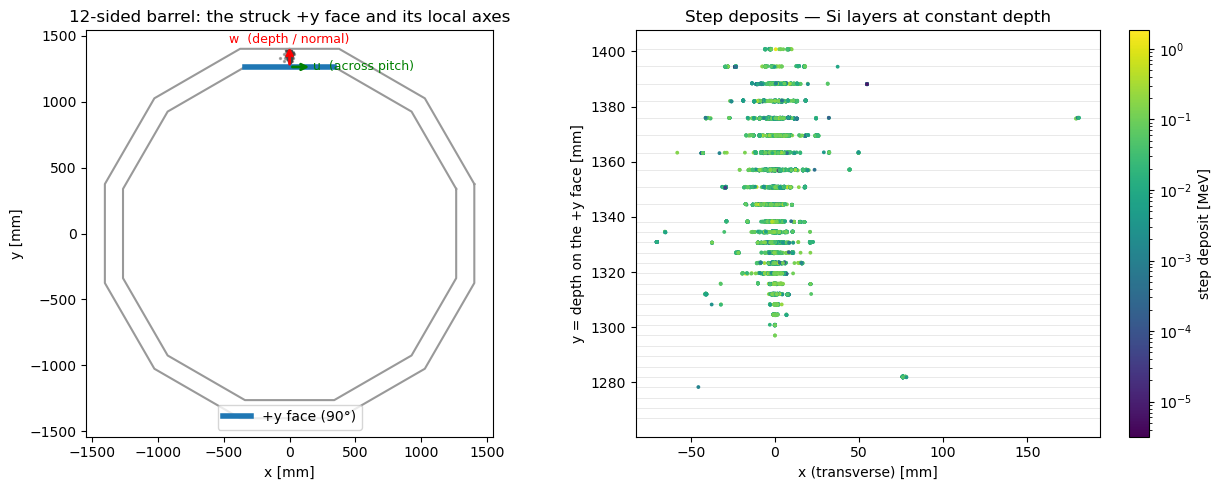

In [2]:
# per-step local-frame quantities, exactly as the crossing builder computes them
centers = scx.si_layer_centers()                                   # 30 Si-layer depths (mm; perpendicular face distance)
phin_s = scx.face_phi(csx, csy)                                    # per-step face normal azimuth
u_s, v_s, w_s = scx.to_local(csx, csy, csz, phin_s)               # local: u across-pitch, v along-z, w depth
layer_s = np.argmin(np.abs(w_s[:, None] - centers[None, :]), axis=1)   # layer by DEPTH (see sec 5)

# The recorded Geant4 step position sits a constant ~0.1 mm into the silicon vs the geometric
# model centre (a step-position convention). It does not affect layer assignment (nearest centre,
# layers are ~4 mm apart), but for depth plots we reference the MEASURED sensor mid-plane per layer.
Z0 = float(np.median(w_s - centers[layer_s]))
cen_data = centers.copy()
for L in np.unique(layer_s):
    cen_data[L] = np.median(w_s[layer_s == L])
print(f"model-vs-recorded depth offset Z0 = {Z0*1000:.0f} um (model already includes the 0.1 mm stack tolerance)")
print(f"  (Z0 does not change layer assignment -- layers are ~4 mm apart -- nor the per-crossing records, which store the mid-plane impact.)")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# (a) 12-gon schematic with the +y face and the local axes
Rin = scx.ECAL_RMIN_MM / np.cos(np.radians(15)); Rout = scx.ECAL_RMAX_MM / np.cos(np.radians(15))
vang = np.radians(np.arange(15, 376, 30))
ax[0].plot(Rin*np.cos(vang), Rin*np.sin(vang), color="0.6"); ax[0].plot(Rout*np.cos(vang), Rout*np.sin(vang), color="0.6")
xf = scx.ECAL_RMIN_MM * np.tan(np.radians(15)); r0 = scx.ECAL_RMIN_MM
ax[0].plot([-xf, xf], [r0, r0], color="#1f77b4", lw=4, label="+y face (90°)")
ax[0].annotate("", xy=(0, r0+170), xytext=(0, r0), arrowprops=dict(arrowstyle="->", color="r", lw=2))
ax[0].annotate("", xy=(170, r0), xytext=(0, r0), arrowprops=dict(arrowstyle="->", color="g", lw=2))
ax[0].text(0, r0+185, "w  (depth / normal)", color="r", ha="center", fontsize=9)
ax[0].text(180, r0, "u  (across pitch)", color="g", va="center", fontsize=9)
ax[0].scatter(csx[::25], csy[::25], s=2, color="#444", alpha=0.4, zorder=0)
ax[0].set_aspect("equal"); ax[0].set_xlabel("x [mm]"); ax[0].set_ylabel("y [mm]")
ax[0].set_title("12-sided barrel: the struck +y face and its local axes"); ax[0].legend(loc="lower center")
# (b) the steps on that face: layers sit at constant depth (horizontal lines)
sc = ax[1].scatter(csx, csy, s=3, c=cE*1e3, cmap="viridis", norm=LogNorm())
for c in centers: ax[1].axhline(c, color="0.85", lw=0.4, zorder=0)
ax[1].set_xlabel("x (transverse) [mm]"); ax[1].set_ylabel("y = depth on the +y face [mm]")
ax[1].set_title("Step deposits — Si layers at constant depth"); plt.colorbar(sc, ax=ax[1], label="step deposit [MeV]")
plt.tight_layout(); plt.show()

## 4. Detailed mode resolves position *inside* each 320 µm sensor

The payoff of detailed mode: each step is localized **within** the silicon, not just attributed
to a pixel. The left panel shows every step's depth relative to the **sensor mid-plane** — the
deposits sit inside the ±0.16 mm (320 µm) silicon, exactly as they should. (The layer model in `sensor_crossings.si_layer_centers` already
includes the driver's 0.1 mm stack-placement tolerance, so the recorded step depths match the
model mid-planes — `Z0 ≈ 0` is printed above, confirming there is no residual offset to correct;
the per-layer measured median is used below only as a robust reference.) The right panel makes the "one or several steps per crossing"
point from §3 concrete: it counts the Geant4 steps in each crossing. It peaks at **one step** — a
fast particle pierces the thin sensor in a single increment — with a tail to several (slower,
steeper, or scattered tracks). This is not bookkeeping trivia: a crossing's direction is measured
from the displacement between its **first and last** step, so a single-step crossing has no
internal lever arm and must take its direction from the producing particle's momentum instead
(§6).

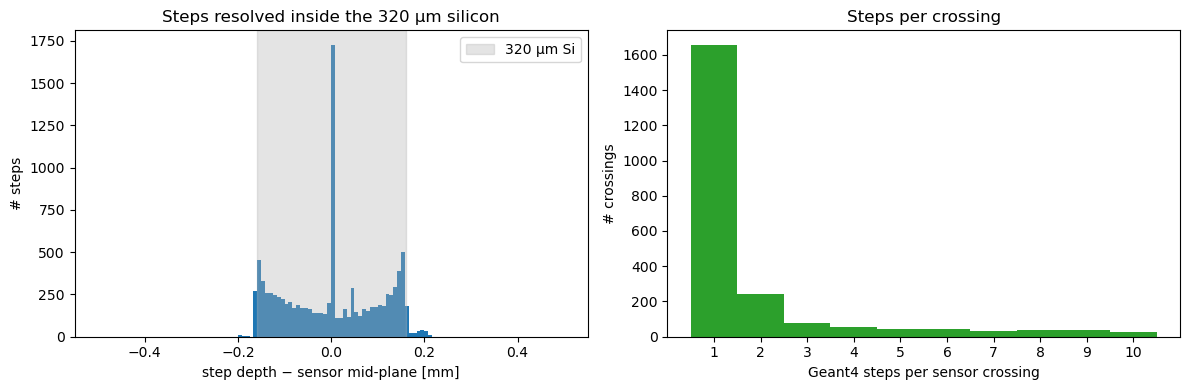

built 2,535 per-sensor charged-track crossings; stats: {'neutral_groups_skipped': 24, 'dir_from_momentum': 1672}


In [3]:
segs, stats = scx.build_segments_A(d)   # the per-sensor crossings (the payload)
ns = np.array([s["n_steps"] for s in segs])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
resid_step = w_s - cen_data[layer_s]
ax[0].hist(resid_step, bins=120, range=(-0.5, 0.5), color="#1f77b4")
ax[0].axvspan(-scx.SI_THICK_MM/2, scx.SI_THICK_MM/2, color="0.7", alpha=0.35, label="320 µm Si")
ax[0].set_xlabel("step depth − sensor mid-plane [mm]"); ax[0].set_ylabel("# steps")
ax[0].set_title("Steps resolved inside the 320 µm silicon"); ax[0].legend()
ax[1].hist(ns, bins=np.arange(1, 12)-0.5, color="#2ca02c")
ax[1].set_xlabel("Geant4 steps per sensor crossing"); ax[1].set_ylabel("# crossings")
ax[1].set_title("Steps per crossing"); ax[1].set_xticks(range(1, 11))
plt.tight_layout(); plt.show()
print(f"built {len(segs):,} per-sensor charged-track crossings; stats: {stats}")

## 5. Two geometry choices, justified by the data

**Why the layer label matters — what it is used for.** Every crossing must be tagged with *which*
of the 30 sensors it happened in, and that label is load-bearing twice over. First, a sensor-level simulation is configured
**per sensor** — each layer can have its own thickness, bias and field model — so a crossing sent to the wrong layer would be simulated with the wrong sensor model. Second, our
local geometry — the entry depth, the front/back face, and therefore the entry point and direction
we hand over — is measured *relative to that layer's position*, so a wrong label also corrupts the
kinematics. (The label additionally builds the longitudinal shower profile, §7d.) A label error is
not cosmetic: it routes a track to the wrong detector. The two choices below are exactly where that
label is easy to get subtly wrong, so the data has to settle them.

Two reconstruction choices are easy to get subtly wrong; the data settles both.

**(a) Where is the face?** The dodecagon could be oriented with a face *centre* or a *vertex* at
+y. The step-azimuth distribution peaks sharply at **90°**, so the +y beam strikes a face
*centre* there: face centres sit at `k·30°` (i.e. `FACE_PHI0 = 0`, not the 15° offset one might
assume from the geometry's 15° rotation). Getting this wrong by 15° throws the local entry point
off by `r·sin15° ≈ 300 mm`.

**(b) What labels a layer — radius or depth?** The sensors are **flat**, so a layer sits at
constant **depth** `w` (perpendicular distance to the face), *not* constant radius
`r = √(x²+y²)`. For an off-axis step (x up to ~180 mm here) `r` runs up to ~12 mm larger than
`w`, so assigning the layer by radius mislabels the wide-shower steps into the wrong (deeper)
layer. Assigning by **depth** keeps every step within ~0.2 mm of its geometric layer centre
(sub-millimetre; the layer model already includes the 0.1 mm stack offset, so there is no residual
offset to remove — see §4 and §8). The
right panel shows both — radius-based assignment has a fat mislabelling tail; depth-based is tight.

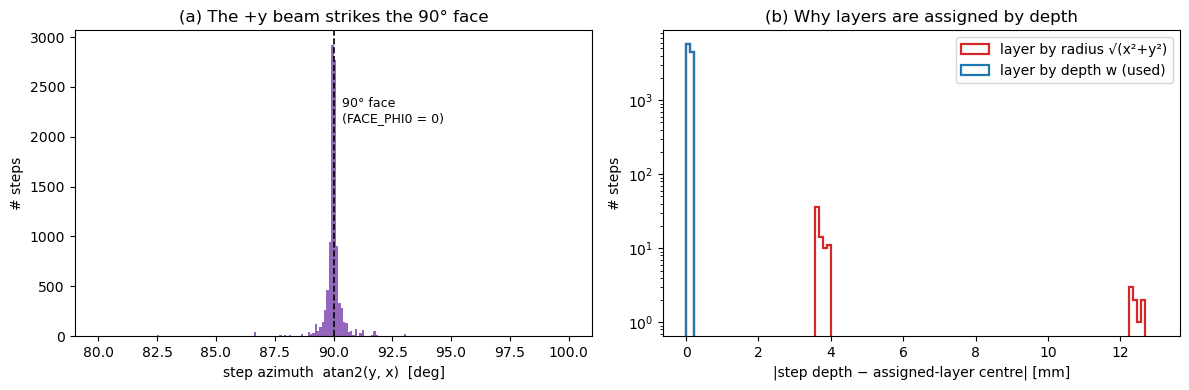

depth residual: by-radius max = 12.6 mm | by-depth max = 0.16 mm


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# (a) step azimuth -> the face is at 90 deg
phi_deg = np.degrees(np.arctan2(csy, csx))
ax[0].hist(phi_deg, bins=200, range=(80, 100), color="#9467bd")
ax[0].axvline(90, ls="--", color="k", lw=1.2)
ax[0].text(90.2, ax[0].get_ylim()[1]*0.7, " 90° face\n (FACE_PHI0 = 0)", fontsize=9)
ax[0].set_xlabel("step azimuth  atan2(y, x)  [deg]"); ax[0].set_ylabel("# steps")
ax[0].set_title("(a) The +y beam strikes the 90° face")
# (b) depth residual: layer-by-radius (wrong) vs layer-by-depth (used)
r_s = np.sqrt(csx**2 + csy**2)
lay_by_r = np.argmin(np.abs(r_s[:, None] - centers[None, :]), axis=1)
resid_if_r = np.abs(w_s - centers[lay_by_r])     # depth residual if layer assigned by radius
resid_w    = np.abs(w_s - centers[layer_s])      # depth residual with depth-based assignment
ax[1].hist(resid_if_r, bins=120, range=(0, 13), histtype="step", lw=1.6, color="#d62728", label="layer by radius √(x²+y²)")
ax[1].hist(resid_w,    bins=120, range=(0, 13), histtype="step", lw=1.6, color="#1f77b4", label="layer by depth w (used)")
ax[1].set_yscale("log"); ax[1].set_xlabel("|step depth − assigned-layer centre| [mm]"); ax[1].set_ylabel("# steps")
ax[1].set_title("(b) Why layers are assigned by depth"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"depth residual: by-radius max = {resid_if_r.max():.1f} mm | by-depth max = {resid_w.max():.2f} mm")

## 6. From steps to crossings — the reconstruction

For each `(MCParticle, face)` the builder **time-orders** the steps and splits them into
maximal **runs of constant layer**: each run is one sensor crossing. Within a run:
- the **impact point** is the *earliest-in-time* step (nearest the face the track enters;
  for a single-step crossing the recorded position is that step's midpoint, ~mid-sensor);
- the **direction** is the entry→exit displacement **in time order** — which is correct for
  *both* inward- and outward-going tracks (a backscattered electron moving toward smaller radius
  gets the right sign), and robust to scattering/curvature. A single-step crossing has no
  displacement, so its direction falls back to the producing particle's momentum.

Time-ordering matters: using the radial min→max step instead would always point *outward* and
**flip the cot signs for every inward-going (backscattered) track**.

**The two panels:**

*Left — one particle threading the detector.* Each dot is a single step (an energy deposit),
coloured by time; the open black circles mark where each per-sensor crossing **begins** (its entry
step). This is one charged particle moving outward through the layers, depositing as it goes — literally what "one track → several sensor crossings" looks like. The crossings fall one-per-layer along a smooth, roughly straight trajectory,
exactly as a real track through a layered detector must.

*Right — two crossings up close, in the sensor's own frame.* The axes are `u` (across the pixel
pitch) and depth `w` through the 320 µm silicon (grey band); the ★ marks the entry. The **red
curve** is a *soft* crossing: its several steps trace an angled path from one face to the other, so
its direction is taken from the entry→exit displacement (this one even enters from the *back* face
— an inward-going track — which time-ordering handles correctly). The **blue arrow** is a *hard*
crossing: a single step, so there is no internal path to measure and the direction comes from the
particle's momentum, drawn as the straight line a sensor-level code transports across the depth — here
essentially perpendicular (cot ≈ 0). The reconstruction returns exactly what the physics demands: a perpendicular hard track and a wide-angle soft one, each with a
well-defined entry on a sensor face — i.e. a sensible crossing record.

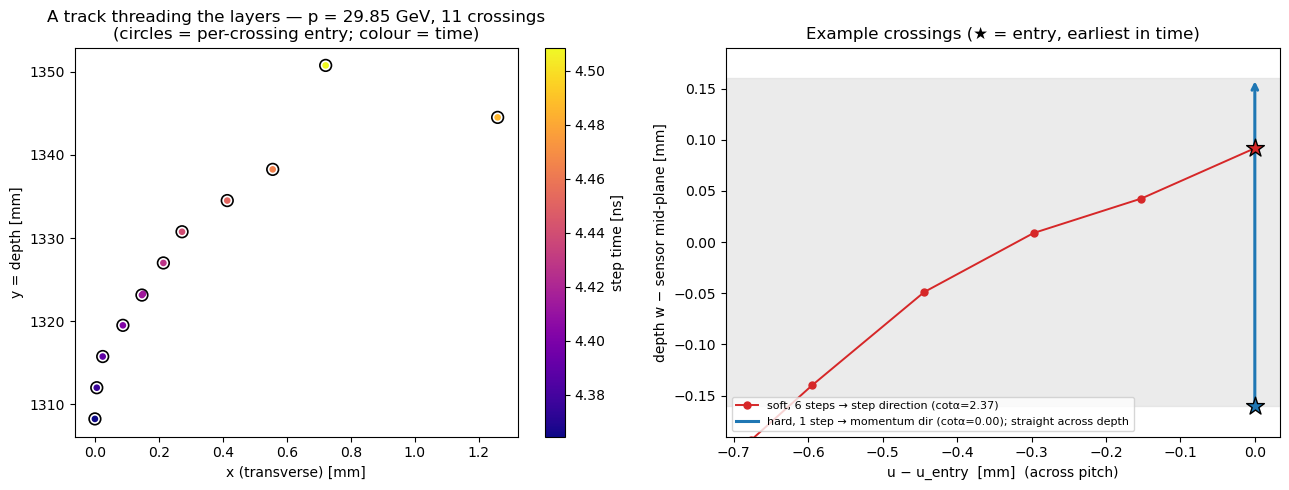

most-threading track 4964: p = 29.85 GeV, crosses 11 sensors


In [5]:
from collections import Counter
def crossing_steps(tid, lay):
    idx = np.where((cmc == tid) & (layer_s == lay))[0]
    return idx[np.argsort(ct[idx])]   # time-ordered

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# left: the track that crosses the most sensors -- a clean "threading" example
tid_best = Counter(s["track_id"] for s in segs).most_common(1)[0][0]
mB = np.where(cmc == tid_best)[0]; segB = [s for s in segs if s["track_id"] == tid_best]
sc = ax[0].scatter(csx[mB], csy[mB], c=ct[mB], s=14, cmap="plasma")
for s in segB:
    ix = crossing_steps(tid_best, s["layer_id"])[0]
    ax[0].scatter(csx[ix], csy[ix], s=70, facecolors="none", edgecolors="k", lw=1.2, zorder=5)
ax[0].set_xlabel("x (transverse) [mm]"); ax[0].set_ylabel("y = depth [mm]")
ax[0].set_title(f"A track threading the layers — p = {segB[0]['p_GeV']:.2f} GeV, {len(segB)} crossings\n"
               f"(circles = per-crossing entry; colour = time)")
plt.colorbar(sc, ax=ax[0], label="step time [ns]")

# right: the two direction modes, in the local (u, w) frame
soft = [s for s in segs if s["p_GeV"] < 0.05 and s["n_steps"] >= 4]
hard1 = [s for s in segs if s["p_GeV"] > 1 and "dir_from_momentum" in s["flags"]]
if soft:                                    # multi-step: direction from the step displacement
    s = soft[0]; ix = crossing_steps(s["track_id"], s["layer_id"])
    uu = u_s[ix] - u_s[ix][0]; ww = w_s[ix] - cen_data[s["layer_id"]]
    ax[1].plot(uu, ww, "o-", color="#d62728", lw=1.4, ms=5,
               label=f"soft, {s['n_steps']} steps → step direction (cotα={s['cot_alpha']:.2f})")
    ax[1].scatter(uu[0], ww[0], marker="*", s=180, color="#d62728", edgecolor="k", zorder=6)
if hard1:                                   # single-step: the downstream sensor simulation transports the straight track itself
    s = hard1[0]; ca_h = s["cot_alpha"]; hw = scx.SI_THICK_MM/2
    ax[1].annotate("", xy=(ca_h*scx.SI_THICK_MM, hw), xytext=(0, -hw),
                   arrowprops=dict(arrowstyle="->", color="#1f77b4", lw=2.2))
    ax[1].scatter(0, -hw, marker="*", s=180, color="#1f77b4", edgecolor="k", zorder=6)
    ax[1].plot([], [], color="#1f77b4", lw=2.2,
               label=f"hard, 1 step → momentum dir (cotα={ca_h:.2f}); straight across depth")
ax[1].axhspan(-scx.SI_THICK_MM/2, scx.SI_THICK_MM/2, color="0.85", alpha=0.5, zorder=0)
ax[1].set_ylim(-0.19, 0.19)
ax[1].set_xlabel("u − u_entry  [mm]  (across pitch)"); ax[1].set_ylabel("depth w − sensor mid-plane [mm]")
ax[1].set_title("Example crossings (★ = entry, earliest in time)"); ax[1].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()
print(f"most-threading track {tid_best}: p = {segB[0]['p_GeV']:.2f} GeV, crosses {len(segB)} sensors")

## 7. The payload — the per-sensor crossing records

The result is one record per crossing with everything a sensor-level simulation needs (the
field-by-field schema is documented in [06 §7](06_sensor_crossings_tracker.ipynb)). The four
panels show:

**(a) Local impact points** — *where on the sensor face* each crossing sits, pooled over **all
30 layers** (every crossing referenced to the same local origin). These are **face** coordinates
measured from the **detector axis** — `u` along the across-pitch direction, `v` along cylinder-z,
with **(0,0) the +y beam axis** — *not* within-a-pixel coordinates. A sensor face is the whole
30° wedge (hundreds of mm across in `u`, the full barrel length in `v`), so the ±tens-of-mm spread
is the **shower's transverse footprint** (a tight core at the axis + a diffuse halo), and has
nothing to do with the 100 µm pitch or the 320 µm depth. The pitch is the *granularity* within
this plane (far finer than a dot); the depth is a separate axis `w` (shown in §6-right and §8.1,
where the ranges are correctly sub-mm).

There are really **two** notions of "position" to keep separate. The **absolute** spot on the
wedge (which sensor, where on the face) matters as bookkeeping — which sensor model to apply,
which crossing this is — while the **sub-pixel** position (where *within* a pixel the track
crosses) is where the device physics lives: charge sharing and cluster shape depend strongly on
it. Our records carry the crossing's real impact, so a downstream tool can either consume the
true sub-pixel position or sample its own — that is the consumer's choice, not ours.

**(b) Direction vs momentum** — `cot α` (the track's slope across the pitch) split into three
momentum bands. Hard tracks (blue) pile up sharply at `cot α ≈ 0` — they cross nearly
perpendicular; soft tracks (red) are broad — they arrive at all angles. The expected EM-shower
behaviour.

**(c) Crossing-momentum spectrum — why it peaks.** It rises to ~10–40 MeV, then
falls. The rise is *not* present in the particle spectrum (which keeps climbing toward low
momentum); it is a **penetration effect**. The shower's tens of thousands of sub-MeV particles
are born inside the dense tungsten and have a range of microns — they are absorbed before they
ever reach a silicon sensor, so they make almost no crossings (in this event ≈36,000 sub-MeV
charged particles produce only ~270 crossings). Only particles energetic enough to escape the
tungsten and reach the silicon register crossings, and harder ones cross more layers each (median
~1 sensor below 1 MeV → ~5 above 1 GeV). The steeply falling production spectrum **times** this
rising reach-and-multiplicity gives a peak at the momentum where particles are both numerous *and*
able to cross sensors.

**(d) Crossings per layer** — the number of charged-track crossings in each of the 30 silicon
layers (0 = front). It rises from the front, peaks around layer ~20, then falls: the classic
**longitudinal shower profile** (the same shape as the energy profile in notebook 05, but counted
in track crossings) — few crossings where the shower is just starting, a maximum at shower max,
then the dying tail.


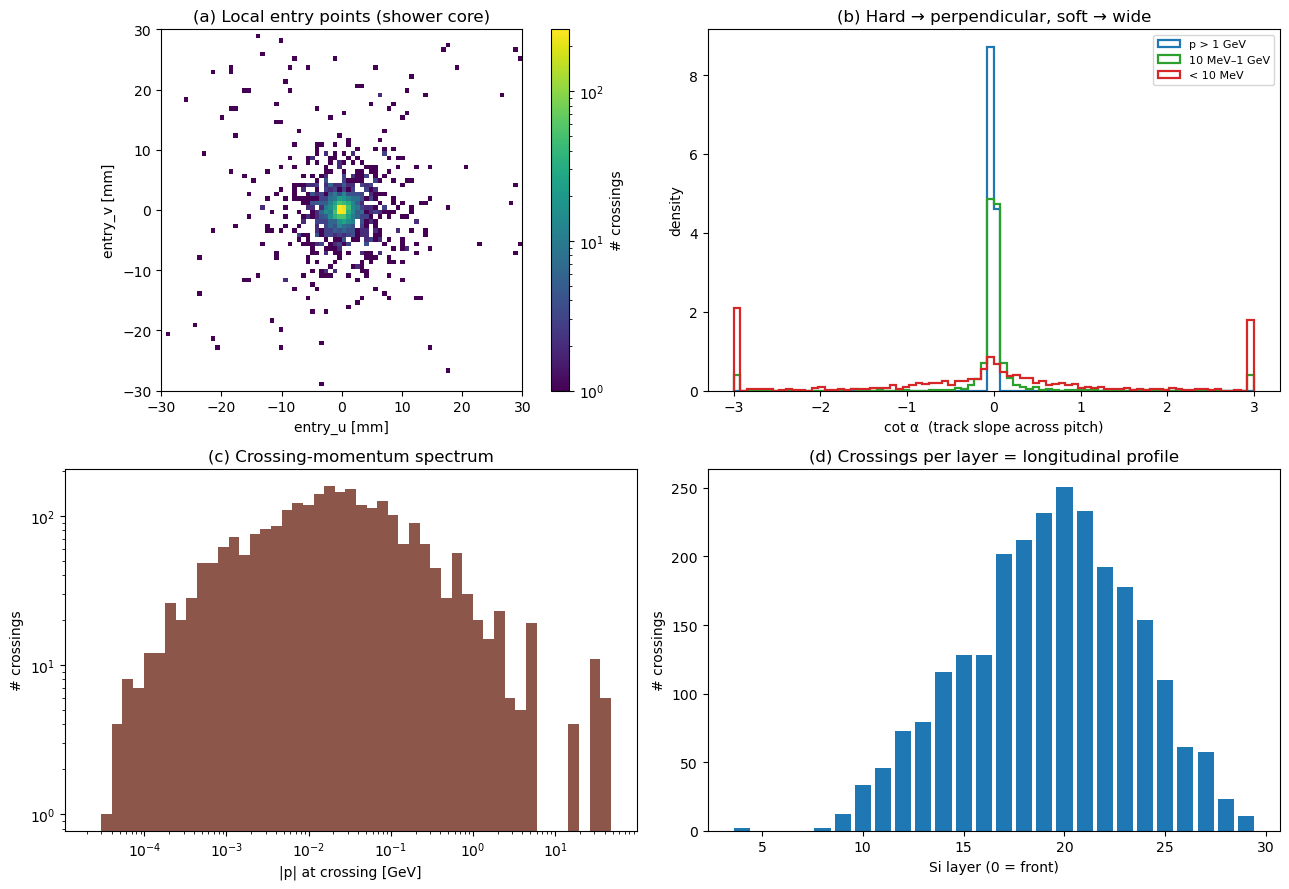

entry_u/v median = (-0.01, -0.01) mm; 95% within (10.0, 10.3) mm
median |cot α|: p>1 GeV = 0.0010  |  p<10 MeV = 0.772


In [6]:
eu = np.array([s["entry_u"] for s in segs]); ev = np.array([s["entry_v"] for s in segs])
ca = np.array([s["cot_alpha"] for s in segs]); cb = np.array([s["cot_beta"] for s in segs])
pp = np.array([s["p_GeV"] for s in segs]);     ll = np.array([s["layer_id"] for s in segs])
fa = np.isfinite(ca)

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
# (a) entry points
h = ax[0,0].hist2d(eu, ev, bins=80, range=[[-30, 30], [-30, 30]], cmap="viridis", norm=LogNorm())
ax[0,0].set_xlabel("entry_u [mm]"); ax[0,0].set_ylabel("entry_v [mm]"); ax[0,0].set_aspect("equal")
ax[0,0].set_title("(a) Local entry points (shower core)"); plt.colorbar(h[3], ax=ax[0,0], label="# crossings")
# (b) cot alpha by momentum band
for sel, lab, col in [(pp > 1, "p > 1 GeV", "#1f77b4"), ((pp > 0.01) & (pp <= 1), "10 MeV–1 GeV", "#2ca02c"),
                      (pp <= 0.01, "< 10 MeV", "#d62728")]:
    s = sel & fa
    if s.any(): ax[0,1].hist(np.clip(ca[s], -3, 3), bins=80, range=(-3, 3), histtype="step", lw=1.6, color=col, label=lab, density=True)
ax[0,1].set_xlabel("cot α  (track slope across pitch)"); ax[0,1].set_ylabel("density")
ax[0,1].set_title("(b) Hard → perpendicular, soft → wide"); ax[0,1].legend(fontsize=8)
# (c) momentum spectrum
ax[1,0].hist(pp[pp > 0], bins=np.logspace(np.log10(pp[pp>0].min()), np.log10(pp.max()), 50), color="#8c564b")
ax[1,0].set_xscale("log"); ax[1,0].set_yscale("log"); ax[1,0].set_xlabel("|p| at crossing [GeV]")
ax[1,0].set_ylabel("# crossings"); ax[1,0].set_title("(c) Crossing-momentum spectrum")
# (d) crossings per layer
Ls, cs = np.unique(ll, return_counts=True)
ax[1,1].bar(Ls, cs, color="#1f77b4"); ax[1,1].set_xlabel("Si layer (0 = front)"); ax[1,1].set_ylabel("# crossings")
ax[1,1].set_title("(d) Crossings per layer = longitudinal profile")
plt.tight_layout(); plt.show()
print(f"entry_u/v median = ({np.median(eu):.2f}, {np.median(ev):.2f}) mm; 95% within "
      f"({np.percentile(np.abs(eu),95):.1f}, {np.percentile(np.abs(ev),95):.1f}) mm")
print(f"median |cot α|: p>1 GeV = {np.median(np.abs(ca[(pp>1)&fa])):.4f}  |  p<10 MeV = {np.median(np.abs(ca[(pp<0.01)&fa])):.3f}")

## 8. Validation — does the per-crossing table hold up?

These two plots verify the internal consistency of the per-crossing records; they are not new physics. Explicitly:

**(1) Entry depth inside the sensor.** For each crossing we take its recorded entry depth and
subtract the *measured* mid-plane of the sensor it was assigned to; the result should be small,
because an entry sits within the 320 µm sensor — within ~half the thickness (0.16 mm, the dashed
line) of the mid-plane, plus the small statistical scatter of the per-layer median reference (max
0.21 mm here). The expected shape is a tall spike near zero: most crossings are single-step
(recorded essentially at the mid-plane → residual ≈ 0), with a tail out toward a face (≈ 0.16 mm). It says every crossing really does sit inside the 320 µm sensor it
was labelled with — the layer label and the local depth agree.

**(2) Hard → collimated, soft → wide.** A 2-D density of each crossing's direction steepness,
`|cot| = √(cot α² + cot β²)`, versus its momentum, with the median in cyan. It restates panel
7(b) across the full momentum range: at high `|p|` (right) the density and the median collapse to
`|cot| ≈ 0` (perpendicular); toward low `|p|` they fan out to large angles. The sparse upper-left
is simply that few crossings are both very soft *and* very steep. Again a consistency check — a
crossing's angle is set almost entirely by the particle's momentum, as it must be.

The cell also prints the **inward vs outward** split: a real fraction of crossings are
inward-going (backscattered tracks heading to smaller radius), and time-ordering gives them the
correct `cot` sign — a radial min→max scheme would have silently flipped it.

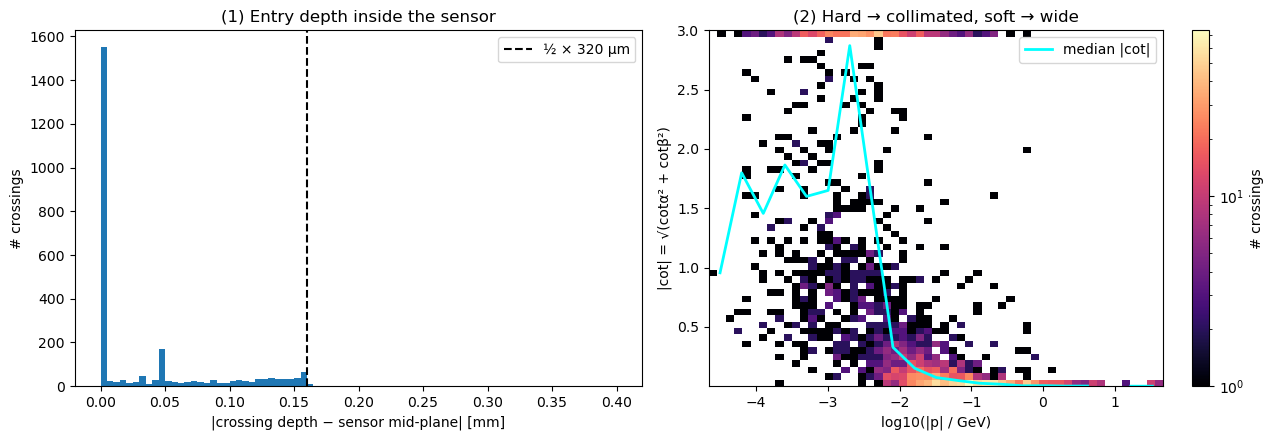

depth residual: median = 0.000 mm, max = 0.210 mm (≲ ½ Si thickness; entry at the face)
multi-step crossings: 626 outward, 253 inward — both get the correct cot sign via time order


In [7]:
# (1) depth residual per crossing; (2) |cot| vs |p| map
dw = np.array([s["depth_w_mm"] for s in segs]); resid = np.abs(dw - cen_data[ll])
cot_mag = np.hypot(np.clip(ca, -50, 50), np.clip(cb, -50, 50))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(resid, bins=80, range=(0, 0.4), color="#1f77b4")
ax[0].axvline(scx.SI_THICK_MM/2, ls="--", color="k", label="½ × 320 µm")
ax[0].set_xlabel("|crossing depth − sensor mid-plane| [mm]"); ax[0].set_ylabel("# crossings")
ax[0].set_title("(1) Entry depth inside the sensor"); ax[0].legend()
sel = fa & (pp > 0)
le = np.log10(np.clip(pp[sel], 1e-5, None))
hh = ax[1].hist2d(le, np.clip(cot_mag[sel], 0, 3), bins=[55, 55], cmap="magma", norm=LogNorm())
xb = np.linspace(le.min(), le.max(), 22); xc = 0.5*(xb[:-1]+xb[1:])
medc = [np.median(cot_mag[sel][(le >= lo) & (le < hi)]) if ((le >= lo) & (le < hi)).any() else np.nan
        for lo, hi in zip(xb[:-1], xb[1:])]
ax[1].plot(xc, medc, color="cyan", lw=2, label="median |cot|")
ax[1].set_xlabel("log10(|p| / GeV)"); ax[1].set_ylabel("|cot| = √(cotα² + cotβ²)")
ax[1].set_title("(2) Hard → collimated, soft → wide"); ax[1].legend()
plt.colorbar(hh[3], ax=ax[1], label="# crossings")
plt.tight_layout(); plt.show()

# (3) inward-going crossings (multi-step, so direction comes from the step displacement)
inward = 0; outward = 0
for s in segs:
    ix = crossing_steps(s["track_id"], s["layer_id"])
    if len(ix) >= 2:
        if (w_s[ix[-1]] - w_s[ix[0]]) < 0: inward += 1
        else: outward += 1
print(f"depth residual: median = {np.median(resid):.3f} mm, max = {resid.max():.3f} mm (≲ ½ Si thickness; entry at the face)")
print(f"multi-step crossings: {outward} outward, {inward} inward — both get the correct cot sign via time order")

## 9. Absolute scale — the crossings deposit a silicon MIP

Every check so far is *internal* self-consistency of the calorimeter route. Two checks anchor it to physics **outside** this notebook, using only 07's own data (no tracker run needed), so 07 stands on its own:

**(a) The deposit is a real MIP.** Each crossing record carries `energy_dep_GeV` — the sum of the Geant4 step energies inside that sensor. A relativistic track crossing the full 320 µm must deposit the silicon **MIP**: a Landau distribution with most-probable value ~85 keV, exactly the value the calorimeter pipeline (notebooks 01/02) is normalised to. We select near-perpendicular, full-thickness crossings — path length ≈ the 320 µm thickness, estimated geometrically from the direction cosines, `path = t·√(1 + cot²α + cot²β)` — and confirm the Landau peak lands there.

**(b) The crossings trace the energy profile.** The number of crossings per layer should follow the same longitudinal shape as the deposited energy per layer; if it did not, the crossing count would be a biased sampler of the shower. Both come straight from this event's step truth.

(Notebook [06 §8](06_sensor_crossings_tracker.ipynb) does the stronger cross-check — that the calorimeter and tracker readouts are byte-identically the *same* shower; here we confirm the absolute scale from the calorimeter side alone.)

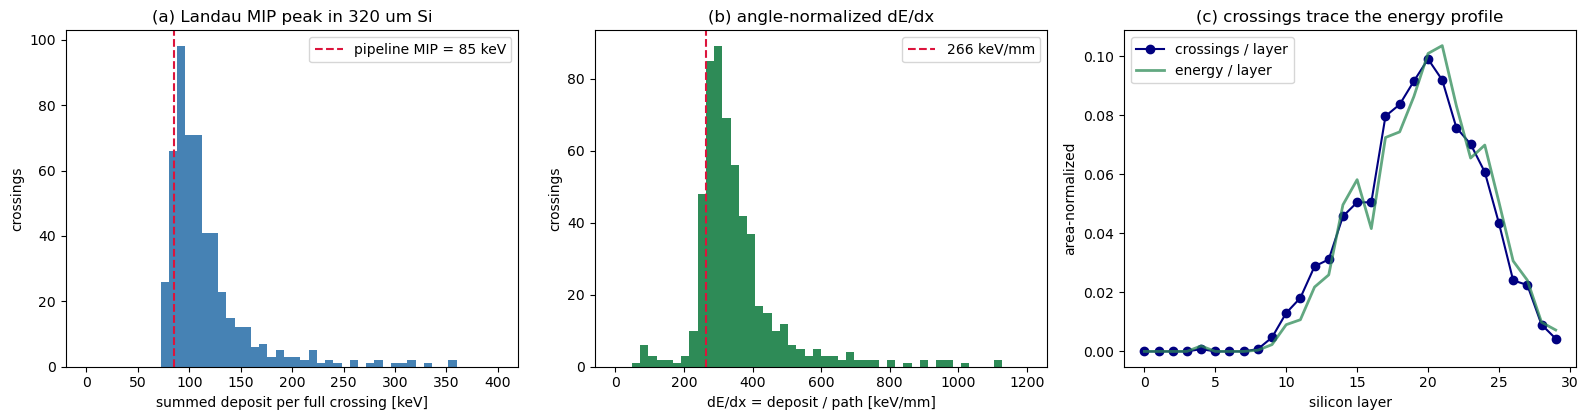

full-thickness crossings n=529: Landau MPV ~ 92 keV (pipeline MIP 85 keV)
crossings-vs-energy longitudinal shape correlation: 0.987  (1.000 = identical shape)
-> the calo-route deposits sit on the silicon MIP, and the crossing count faithfully
   traces the energy profile -- 07's absolute scale is anchored without the tracker run.


In [8]:
seg_dep = np.array([s["energy_dep_GeV"] for s in segs]) * 1e6   # keV, summed step energy per crossing
seg_ca  = np.array([s["cot_alpha"] for s in segs]); seg_cb = np.array([s["cot_beta"] for s in segs])
seg_lay = np.array([s["layer_id"] for s in segs]);  seg_p  = np.array([s["p_GeV"] for s in segs])
# geometric path through the 320 um sensor from the direction cosines (perpendicular -> thickness)
cot2 = np.clip(seg_ca**2 + seg_cb**2, 0, 100)
path = scx.SI_THICK_MM * np.sqrt(1.0 + cot2)
rel  = seg_p > 0.1                                    # relativistic -> on the MIP plateau
full = rel & (path > 0.30) & (path < 0.40)            # near-perpendicular, ~full 320 um
MIP_keV = 85.0
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
ax[0].hist(seg_dep[full], bins=50, range=(0, 400), color="steelblue")
ax[0].axvline(MIP_keV, color="crimson", ls="--", label=f"pipeline MIP = {MIP_keV:.0f} keV")
ax[0].set_xlabel("summed deposit per full crossing [keV]"); ax[0].set_ylabel("crossings")
ax[0].set_title("(a) Landau MIP peak in 320 um Si"); ax[0].legend()
dedx = seg_dep[rel] / path[rel]
ax[1].hist(dedx, bins=50, range=(0, 1200), color="seagreen")
ax[1].axvline(MIP_keV / 0.32, color="crimson", ls="--", label=f"{MIP_keV / 0.32:.0f} keV/mm")
ax[1].set_xlabel("dE/dx = deposit / path [keV/mm]"); ax[1].set_ylabel("crossings")
ax[1].set_title("(b) angle-normalized dE/dx"); ax[1].legend()
profC = np.bincount(seg_lay, minlength=30).astype(float)
profE = np.zeros(30); np.add.at(profE, layer_s, cE)
L = np.arange(30)
ax[2].plot(L, profC / profC.sum(), "o-", color="navy", label="crossings / layer")
ax[2].plot(L, profE / profE.sum(), "-", color="seagreen", lw=2, alpha=0.75, label="energy / layer")
ax[2].set_xlabel("silicon layer"); ax[2].set_ylabel("area-normalized"); ax[2].legend()
ax[2].set_title("(c) crossings trace the energy profile")
plt.tight_layout(); plt.show()
h, e = np.histogram(seg_dep[full], bins=50, range=(0, 400)); mpv = 0.5 * (e[np.argmax(h)] + e[np.argmax(h) + 1])
corr = np.corrcoef(profC / profC.sum(), profE / profE.sum())[0, 1]
print(f"full-thickness crossings n={int(full.sum())}: Landau MPV ~ {mpv:.0f} keV (pipeline MIP {MIP_keV:.0f} keV)")
print(f"crossings-vs-energy longitudinal shape correlation: {corr:.3f}  (1.000 = identical shape)")
print("-> the calo-route deposits sit on the silicon MIP, and the crossing count faithfully")
print("   traces the energy profile -- 07's absolute scale is anchored without the tracker run.")

## 10. The shower behind these crossings — the full particle cascade

The crossings in §6–§8 were reconstructed from the calorimeter step truth. That same `fullcascade` file also carries the complete MCParticle shower — ~78,000 particles for this one 50 GeV photon — so we can restore the full shower these crossings live in, the same event notebook [05](05_shower_4vectors.ipynb) examines, reproduced here so this notebook stands on its own. Every plot below is the particle-level *origin* of something in the crossing table:

- the soft **energy spectrum** is why the crossing-momentum spectrum (§7c) peaks at a few MeV;
- the **opening-angle-vs-energy** trend is the source of the per-crossing `cot` vs `|p|` pattern (§8);
- the **cascade tree** is the branching that fills the 30 layers (§7d).

Because this route works at the step level, the silicon deposits shown below are the calorimeter `SimCalorimeterHit`s — the very collection §3–§4 dissected step by step. (Notebook 05 presents this cascade as its main subject; notebook [06](06_sensor_crossings_tracker.ipynb) shows it from the tracker-readout side.)

In [9]:
# --- the full particle cascade behind the crossings (same event, from the fullcascade npz) ---
# `d` is the fullcascade file this notebook already loaded; besides the per-step truth used to
# reconstruct crossings, it carries the complete MCParticle shower and the calorimeter hits, so
# 07 can tell the whole shower story on its own.
pdg, mass, E = d["pdg"], d["mass"], d["E"]
px, py, pz = d["px"], d["py"], d["pz"]
pex, pey, pez = d["pex"], d["pey"], d["pez"]
vsx, vsy, vsz = d["vsx"], d["vsy"], d["vsz"]
vex, vey, vez = d["vex"], d["vey"], d["vez"]
dbeg, dend, dau = d["dbeg"], d["dend"], d["dau"]
hx, hy, hz, he = d["hx"], d["hy"], d["hz"], d["he"]   # calorimeter SimCalorimeterHits (mm, GeV)
print(f"full cascade behind these crossings: {len(pdg):,} MCParticles, "
      f"{len(hx):,} calorimeter hits, {he.sum():.3f} GeV deposited (sampling ~{he.sum()/50:.2%})")

full cascade behind these crossings: 78,270 MCParticles, 5,395 calorimeter hits, 0.531 GeV deposited (sampling ~1.06%)


### Composition

An EM shower grows by two interleaved processes: **pair production** (γ → e⁺e⁻ in a nucleus's
field) and **bremsstrahlung** (e± radiating γ). They feed each other, so the cascade is
overwhelmingly electrons, positrons and photons.

**Why far more electrons than positrons?** Pair production makes e⁺ and e⁻ in equal numbers,
but electrons get three *extra* sources that create no positrons: **ionization / delta rays**
(any charged particle knocking atomic electrons loose), **Compton scattering**, and the
**photoelectric effect** (both eject atomic electrons). Meanwhile positrons are *removed* by
**annihilation** (e⁺ → γγ) at the end of their range. Net effect: e⁻ outnumber e⁺ by about an
order of magnitude here — a real, expected asymmetry, not a bug.

The handful of neutrons, protons and excited tungsten nuclei (PDG `100074xxxx`) come from
**photonuclear** interactions of shower photons with the W absorber.

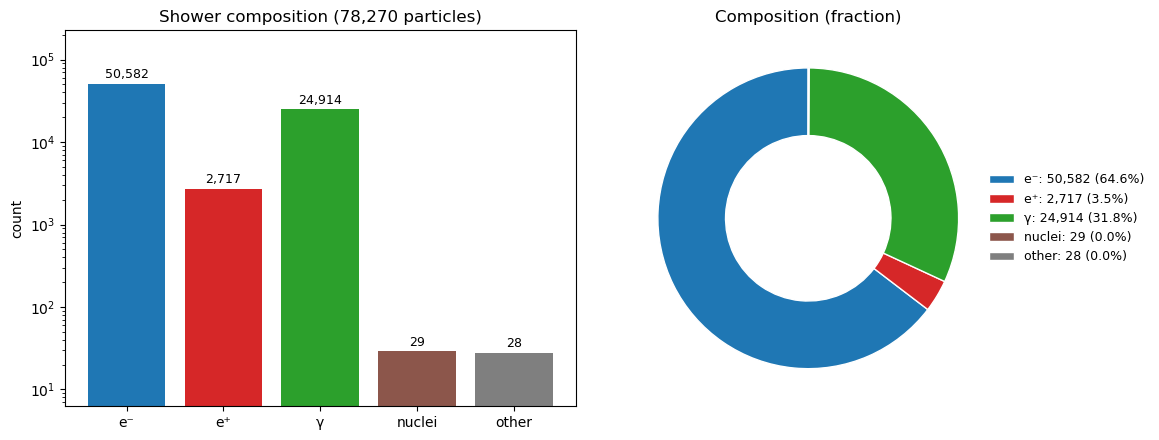

top PDG codes: [(11, 50582), (22, 24914), (-11, 2717), (2112, 24), (2212, 4), (1000741830, 4), (1000741820, 4), (1000741810, 4)]


In [10]:
uniq, counts = np.unique(pdg, return_counts=True)
order = np.argsort(-counts)

# Group: e-, e+, gamma, nuclei (|pdg|>1e9), other
groups = {"e⁻": 0, "e⁺": 0, "γ": 0, "nuclei": 0, "other": 0}
for p, c in zip(uniq, counts):
    if p == 11: groups["e⁻"] += c
    elif p == -11: groups["e⁺"] += c
    elif p == 22: groups["γ"] += c
    elif abs(p) > 1_000_000_000: groups["nuclei"] += c
    else: groups["other"] += c
g = {k: v for k, v in groups.items() if v}
cols = ["#1f77b4", "#d62728", "#2ca02c", "#8c564b", "#7f7f7f"][:len(g)]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
bars = ax[0].bar(g.keys(), g.values(), color=cols)
ax[0].set_yscale("log"); ax[0].set_ylabel("count")
ax[0].set_title(f"Shower composition ({len(pdg):,} particles)")
ax[0].bar_label(bars, fmt="{:,.0f}", padding=2, fontsize=9)
ax[0].margins(y=0.2)

# Pie: labels go in a legend (avoids overlap on the tiny nuclei/other slices);
# percentages are drawn only on slices large enough to read.
total = sum(g.values())
wedges, _ = ax[1].pie(list(g.values()), colors=cols, startangle=90,
                      wedgeprops=dict(width=0.45, edgecolor="w"))
ax[1].set_title("Composition (fraction)")
ax[1].legend(wedges, [f"{k}: {v:,} ({v/total:.1%})" for k, v in g.items()],
             loc="center left", bbox_to_anchor=(0.95, 0.5), frameon=False, fontsize=9)
plt.tight_layout(); plt.show()
print("top PDG codes:", [(int(uniq[i]), int(counts[i])) for i in order[:8]])

### Energy spectrum

**Left — the spectrum itself.** Each shower generation roughly *halves* the energy while
*doubling* the particle count, so the number of secondaries climbs steeply toward low energy:
a near-power-law fall spanning many decades. Multiplication stops once particles drop below
the ~MeV scale (e± can no longer pair-produce or radiate efficiently), so the cascade "dies"
into a sea of soft e±/γ. The few entries far to the right are the *top* of the cascade: the
primary and its first-conversion e⁺e⁻, carrying tens of GeV.

**The three species have distinctly different shapes:**
- **γ (green)** reaches the **lowest energies** — down to ~1 keV here. Photons keep being made
  throughout the cascade (bremsstrahlung, atomic de-excitation) and, being massless, their
  *total* energy *is* their kinetic energy, so there is no floor. Below ~1 MeV they can no
  longer pair-produce, so they stop multiplying but linger as a soft sea until photoelectric
  absorption finally removes them. The 0.511 MeV spike (next paragraph) rides on top.
- **e⁻ (blue)** falls steeply and sits **above e⁺ at every energy** (the extra electron-only
  sources noted in the composition above). Both e± spectra **stop dead at 0.511 MeV**: a particle's *total*
  energy E = √(p²+m²) can never fall below its rest mass mₑc² = 0.511 MeV, so a stopped
  electron (KE → 0) piles up right at that edge. It is the *same* 0.511 MeV as the photon line —
  same mₑc², different reason (rest-mass floor vs annihilation photons).
- **e⁺ (red)** tracks e⁻ at high energy (pair production is symmetric) but is depleted toward
  the floor — stopped positrons **annihilate**, which is what feeds the photon line.

**The sharp photon spike at 0.511 MeV is the positron-annihilation line** — a real spectral
*line*, not a threshold. Every positron, once it slows to rest in the dense W/Si, annihilates
with an atomic electron (**e⁺e⁻ → 2γ**), emitting two back-to-back photons each carrying
exactly the electron rest energy, mₑc² = 511 keV. With thousands of positrons stopping in the
calorimeter these monoenergetic photons pile up: here **~20% of all photons** sit within a few
percent of 511 keV. (The dotted marker sits at mₑc² for exactly this reason.)

**Right — where the energy actually is.** The cumulative curve shows the central tension of
calorimetry: although almost all *particles* are soft, almost all the *energy* is carried by
the handful of *hard* particles near the top of the cascade. Yet the measurable **signal**
(the silicon hits) is made by the enormous number of soft particles ionizing the sensors — so
a good calorimeter has to faithfully collect charge from the soft sea, even though the energy
"lives" in a few hard tracks.

**Why nuclei are excluded from this plot.** The quantity plotted is *total* energy
E = √(p² + m²). For e±/γ the rest mass is negligible, so E is essentially the kinematic
(shower-relevant) energy. But a recoiling nucleus — e.g. a tungsten ion, m ≈ 173 GeV — is
nearly at rest with only keV–MeV of kinetic energy; its *total* energy is almost entirely rest
mass, which would plant spurious ~170-GeV entries far off the right edge and misrepresent the
shower.

> ⚠️ **A 50 GeV photon, yet "particles" at 173 GeV?** Not an energy-budget violation. That
> ~173 GeV is a tungsten nucleus's **rest mass** (E = mc², ~184 nucleons) — it was already
> sitting in the absorber before the event, *not* energy delivered by the photon. The photon
> only gives the nucleus a **≤ MeV recoil**; its 50 GeV is fully conserved, spent on the
> *kinetic* energies of the shower. The kinetic-energy plot below makes this obvious: the
> nuclei drop to keV–MeV, where they belong.

(The nuclei are also a negligible handful and don't drive the EM cascade.)

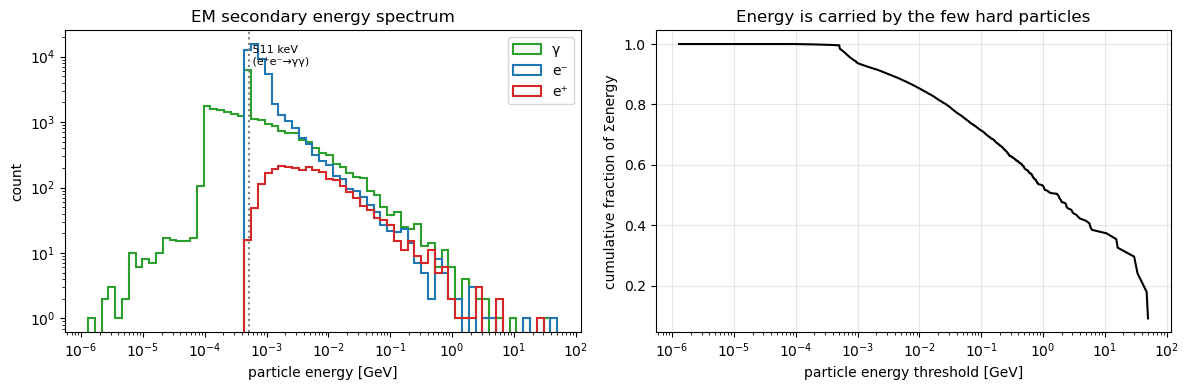

median EM particle energy: 0.66 MeV
# EM particles above 1 GeV: 43 (0.05%)
photons within +/-5% of 511 keV: 21.8%  (expected 2*N(e+)/N(gamma) = 21.8%: two annihilation photons per stopped positron)


In [11]:
em = (pdg == 11) | (pdg == -11) | (pdg == 22)
Eem = E[em]
Eem = Eem[Eem > 0]
assert Eem.size, "no EM (e/gamma) particles with E>0 in this event — energy-spectrum plot needs them"

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
bins = np.logspace(np.log10(max(Eem.min(), 1e-6)), np.log10(Eem.max()), 70)   # down to ~keV: show the full soft sea
for sel, lab, col in [(pdg == 22, "γ", "#2ca02c"), (pdg == 11, "e⁻", "#1f77b4"), (pdg == -11, "e⁺", "#d62728")]:
    es = E[sel]; es = es[es > 0]
    ax[0].hist(es, bins=bins, histtype="step", label=lab, color=col, lw=1.5)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("particle energy [GeV]"); ax[0].set_ylabel("count")
ax[0].set_title("EM secondary energy spectrum"); ax[0].legend()
ax[0].axvline(0.000511, ls=":", color="grey"); ax[0].text(0.000511, ax[0].get_ylim()[1]*0.3, " 511 keV\n (e⁺e⁻→γγ)", fontsize=8)

es = np.sort(Eem)[::-1]
ax[1].plot(es, np.cumsum(es)/es.sum(), color="black")
ax[1].set_xscale("log"); ax[1].set_xlabel("particle energy threshold [GeV]")
ax[1].set_ylabel("cumulative fraction of Σenergy"); ax[1].set_title("Energy is carried by the few hard particles")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"median EM particle energy: {np.median(Eem)*1000:.2f} MeV")
print(f"# EM particles above 1 GeV: {(Eem>1).sum():,} ({(Eem>1).mean():.2%})")
_g = E[pdg == 22]; _frac = np.mean(np.abs(_g - 0.000511) < 0.05 * 0.000511)
_exp = 2 * (pdg == -11).sum() / max((pdg == 22).sum(), 1)
print(f"photons within +/-5% of 511 keV: {_frac:.1%}  (expected 2*N(e+)/N(gamma) = {_exp:.1%}: two annihilation photons per stopped positron)")

### Kinetic energy — bringing the nuclei (and hadrons) back

The spectrum above used *total* energy E = √(p²+m²), which is why nuclei had to be dropped
(their E is almost all rest mass). The physically meaningful quantity for a slow, massive
recoil is the **kinetic energy** T = E − m. Plotted in T, every species sits at its true
kinematic energy — so we can show the *whole* particle inventory on one axis, including the
photonuclear neutrons, protons and tungsten nuclei, which land at keV–MeV (not ~170 GeV).

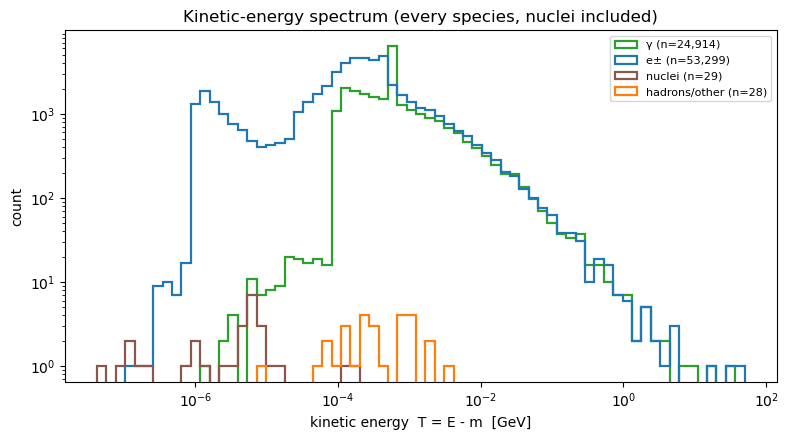

nuclei: n=29, kinetic energy 0.0 eV - 0.2 MeV
  ...their TOTAL energy E would be ~173 GeV (essentially all rest mass)


In [12]:
T = E - mass   # kinetic energy (GeV)
nuc = np.abs(pdg) > 1_000_000_000
groups = [(pdg == 22, "γ", "#2ca02c"), ((pdg == 11) | (pdg == -11), "e±", "#1f77b4"),
          (nuc, "nuclei", "#8c564b"),
          (~nuc & (pdg != 22) & (pdg != 11) & (pdg != -11), "hadrons/other", "#ff7f0e")]
Tpos = T[T > 0]
bins = np.logspace(np.log10(max(Tpos.min(), 1e-9)), np.log10(Tpos.max()), 70)

fig, ax = plt.subplots(figsize=(8, 4.5))
for sel, lab, col in groups:
    t = T[sel & (T > 0)]
    if t.size:
        ax.hist(t, bins=bins, histtype="step", lw=1.6, color=col, label=f"{lab} (n={int(sel.sum()):,})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("kinetic energy  T = E - m  [GeV]"); ax.set_ylabel("count")
ax.set_title("Kinetic-energy spectrum (every species, nuclei included)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
if nuc.any():
    print(f"nuclei: n={int(nuc.sum())}, kinetic energy {T[nuc].min()*1e6:.1f} eV - {T[nuc].max()*1e3:.1f} MeV")
    print(f"  ...their TOTAL energy E would be ~{mass[nuc].max():.0f} GeV (essentially all rest mass)")

### Longitudinal & radial development

The beam travels +y; the ECal front face is at r = 1264 mm. The calorimeter is a stack of
**tungsten-absorber / silicon-sensor** layers (from `my_custom_ecal.xml`): 20 layers of
2.5 mm W + 0.32 mm Si, then 10 layers of 5 mm W + 0.32 mm Si. The shaded **gray bands** in the
first two panels mark the tungsten slabs.

**Left — where particles are born (by species).** The production-vertex profile shows a *comb*
locked to the layers: far more secondaries are created **inside the tungsten** than in the thin
Si/air gaps. Tungsten is dense and high-Z, with a radiation length of only ~3.9 mm (for the
93%-tungsten alloy used here; notebook 01 §3b computes the full budget) versus
~94 mm for silicon — so pair production and bremsstrahlung (which *make* the new particles)
happen overwhelmingly in the absorber. That is the origin of the step-between-bins behaviour:
peaks sit in the gray W bands, dips in the gaps.

**Middle — where energy is measured.** This is built from the **hits**, and hits exist *only in
the silicon* — the tungsten is a passive absorber with no readout. So the deposited-energy
points fall in the thin gaps *between* the W bands (the Si layers), never inside them; the
y-axis here samples only the silicon. As a geometry cross-check, the layer model puts the
deepest Si layer at y ≈ 1400.7 mm, exactly where the last hits are. This panel is not split by
species because a hit does not record which particle deposited it — that link is the
`CaloHitContribution` truth this notebook is built on (§3–§7).

**Right — radial (lateral) profile.** Perpendicular to the beam, energy lands in a tight core
that falls off with transverse radius √(x²+z²) — the lateral spread set by multiple scattering
and the EM Molière radius. The printout reports the 90% / 95% energy-containment radii.

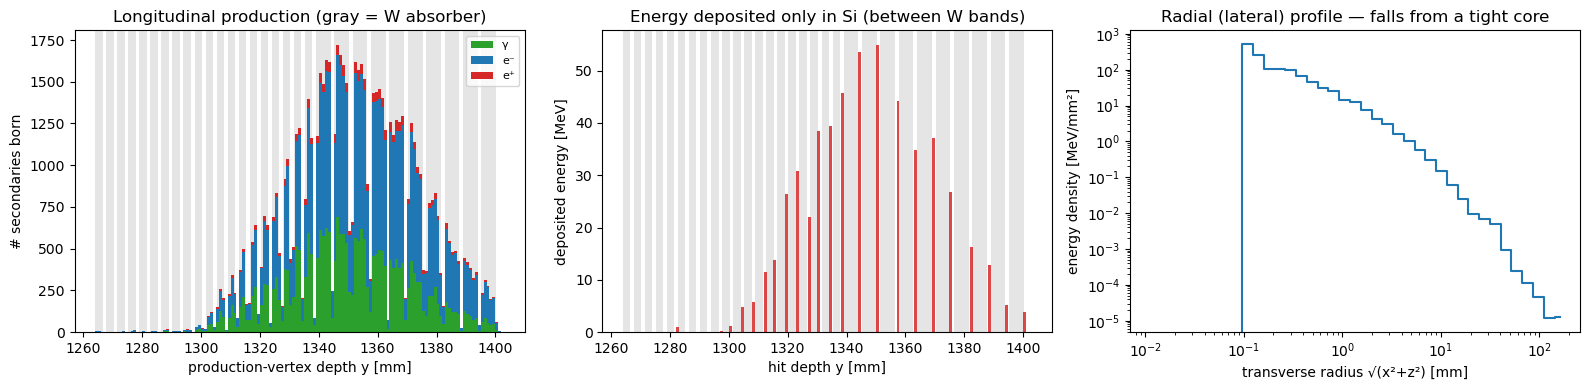

Si-layer model: 30 layers, first y=1266.9 mm, last y=1400.7 mm (deepest hit at y=1400.8 mm — matches)
90% of deposited energy within transverse radius 12.5 mm
95% of deposited energy within transverse radius 23.7 mm


In [13]:
# --- W/Si layer model (geometry/my_custom_ecal.xml; ECal front rmin = 1264 mm) ---
rmin = 1264.0
w_bands, si_pos, yy = [], [], rmin
for nrep, wthick in [(20, 2.5), (10, 5.0)]:
    pitch = wthick + 0.25 + 0.32 + 0.05 + 0.30 + 0.33    # W + air + Si + Cu + Kapton + air (mm)
    for _ in range(nrep):
        w_bands.append((yy, yy + wthick))                # tungsten slab
        si_pos.append(yy + wthick + 0.25 + 0.16)         # silicon-layer centre
        yy += pitch
def draw_W(a):
    for lo, hi in w_bands:
        a.axvspan(lo, hi, color="0.6", alpha=0.25, lw=0)

species = [(pdg == 22, "γ", "#2ca02c"), (pdg == 11, "e⁻", "#1f77b4"), (pdg == -11, "e⁺", "#d62728")]
dbins = np.linspace(rmin, 1403, 140)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

# (a) production by species, stacked, with the W bands behind
draw_W(ax[0])
inwin = (vsy > rmin) & (vsy < 1403)
ax[0].hist([vsy[m & inwin] for m, _, _ in species], bins=dbins, stacked=True,
           label=[lab for _, lab, _ in species], color=[c for _, _, c in species])
ax[0].set_xlabel("production-vertex depth y [mm]"); ax[0].set_ylabel("# secondaries born")
ax[0].set_title("Longitudinal production (gray = W absorber)"); ax[0].legend(fontsize=8)

# (b) energy deposition (hits) -- only in Si, i.e. in the gaps between the W bands
draw_W(ax[1])
ax[1].hist(hy, bins=dbins, weights=he * 1000, color="#d62728", alpha=0.85)
ax[1].set_xlabel("hit depth y [mm]"); ax[1].set_ylabel("deposited energy [MeV]")
ax[1].set_title("Energy deposited only in Si (between W bands)")

# (c) radial / lateral profile -- energy DENSITY (per unit area) so it falls from the core
rho = np.hypot(hx, hz)   # transverse distance from the +y beam axis
rb = np.logspace(np.log10(max(rho[rho > 0].min(), 1e-2)), np.log10(rho.max() + 1), 40)
e_shell, _ = np.histogram(rho, bins=rb, weights=he * 1000)        # MeV per annular shell
area = np.pi * (rb[1:]**2 - rb[:-1]**2)                           # shell area, mm^2
rc = np.sqrt(rb[1:] * rb[:-1])
ax[2].plot(rc, e_shell / area, drawstyle="steps-mid", color="#1f77b4")
ax[2].set_xscale("log"); ax[2].set_yscale("log")
ax[2].set_xlabel("transverse radius √(x²+z²) [mm]"); ax[2].set_ylabel("energy density [MeV/mm²]")
ax[2].set_title("Radial (lateral) profile — falls from a tight core")
plt.tight_layout(); plt.show()

print(f"Si-layer model: {len(si_pos)} layers, first y={si_pos[0]:.1f} mm, last y={si_pos[-1]:.1f} mm "
      f"(deepest hit at y={hy.max():.1f} mm — matches)")
o = np.argsort(rho); cumE = np.cumsum(he[o]) / he.sum(); rsort = np.sort(rho)
for frac in (0.90, 0.95):
    print(f"{frac:.0%} of deposited energy within transverse radius {rsort[np.searchsorted(cumE, frac)]:.1f} mm")

### Shower shape — transverse spread and 3D view

**These plots use the silicon *hits* (energy deposits), not the truth particles.** They show
where energy actually lands in the sensors — the *measurable* shower image — as opposed to the
particle-level views above, which come from the MCParticle truth. (So there
is no per-particle-type breakdown here: a hit only knows its position and deposited energy, not
which particle made it — that link is the `CaloHitContribution` truth §3–§7 reconstruct crossings from.)

Transverse coordinates are x and z (the beam is +y); the shower is narrow near the front and
spreads with depth. Hit positions are colored by deposited energy.

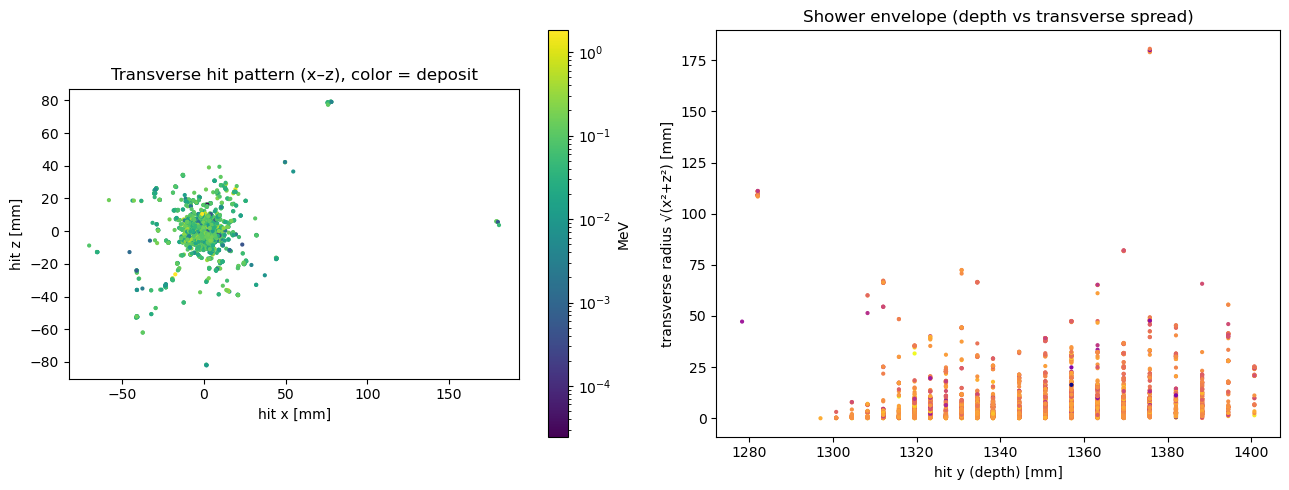

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sc = ax[0].scatter(hx, hz, c=he*1000, s=4, cmap="viridis", norm=plt.matplotlib.colors.LogNorm())
ax[0].set_xlabel("hit x [mm]"); ax[0].set_ylabel("hit z [mm]"); ax[0].set_aspect("equal")
ax[0].set_title("Transverse hit pattern (x–z), color = deposit"); plt.colorbar(sc, ax=ax[0], label="MeV")

rt = np.hypot(hx, hz)
ax[1].scatter(hy, rt, c=he*1000, s=4, cmap="plasma", norm=plt.matplotlib.colors.LogNorm())
ax[1].set_xlabel("hit y (depth) [mm]"); ax[1].set_ylabel("transverse radius √(x²+z²) [mm]")
ax[1].set_title("Shower envelope (depth vs transverse spread)")
plt.tight_layout(); plt.show()

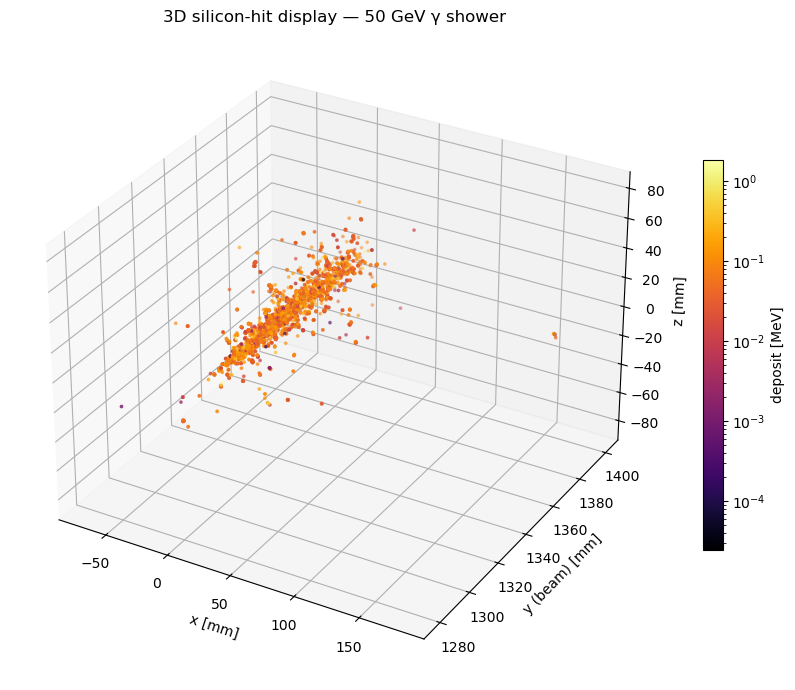

In [15]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
sub = slice(None) if len(hx) < 20000 else np.random.default_rng(0).choice(len(hx), 20000, replace=False)
p = ax.scatter(hx[sub], hy[sub], hz[sub], c=he[sub]*1000, s=3, cmap="inferno",
               norm=plt.matplotlib.colors.LogNorm())
ax.set_xlabel("x [mm]"); ax.set_ylabel("y (beam) [mm]"); ax.set_zlabel("z [mm]")
ax.set_title("3D silicon-hit display — 50 GeV γ shower")
fig.colorbar(p, label="deposit [MeV]", shrink=0.6)
plt.tight_layout(); plt.show()

### Momentum directions

A particle's opening angle is a competition between **relativistic beaming** and **multiple
scattering**. Bremsstrahlung and pair production emit their products within a characteristic
angle ~ mₑc²/E of the parent's direction (higher energy ⇒ tighter cone), so freshly-made *hard*
particles are sharply forward. But once a particle slows to the ~MeV scale, multiple Coulomb
scattering randomises its direction — and since the cascade is overwhelmingly soft (see the energy spectrum above), the
*bulk* of particles end up nearly isotropic. The three panels disentangle this.

**Left — opening angle, by species.** Compare each curve to the dashed reference an *isotropic*
3-D distribution would give (dN/dθ ∝ sinθ, peaking at θ = 90°). The three species look
strikingly different, and the difference is all **production mechanism**:
- **e⁺ (red) are the most forward** — median ≈ 17°, ~35% within 10° of the beam. Positrons are
  made *only* by pair production, which is forward-beamed; there is no positron analogue of
  knock-out electrons, so they stay close to their forward origin.
- **e⁻ (blue) are the widest** — median ≈ 73°, peaking near 90° and with ~36% going *backward*.
  Electrons get the extra wide-angle sources noted above — **delta rays** kicked sideways by
  ionisation, plus Compton and photoelectric electrons — and the huge soft-electron sea is
  fully multiple-scattered, so it traces almost exactly the isotropic sinθ shape.
- **γ (green) sit in between** — median ≈ 49°, with a sharp forward spike. Bremsstrahlung
  photons are beamed forward, while soft photons and the **isotropic 511 keV annihilation
  photons** (emitted every which way by stopped positrons) fill in all the other angles.

**Middle — azimuthal symmetry.** The azimuth φ in the transverse x–z plane is **flat**, as it
must be: beam on-axis, no magnetic field, so no preferred transverse direction. A non-flat φ
would flag a geometry or bookkeeping bug — a cheap but genuine validation.

**Right — collimation vs energy.** The cleanest statement of the beaming-vs-scattering
competition: the median opening angle plunges from ~70° for the soft sea (E < 10 MeV) to
**0.08°** for E > 1 GeV (essentially every hard track is within 10° of the beam). A particle's
angle is set almost entirely by its energy. *This per-track opening angle — direction as a function of how hard the particle is — is the
particle-level origin of the per-crossing `cot` vs `|p|` pattern we validated in §8.*

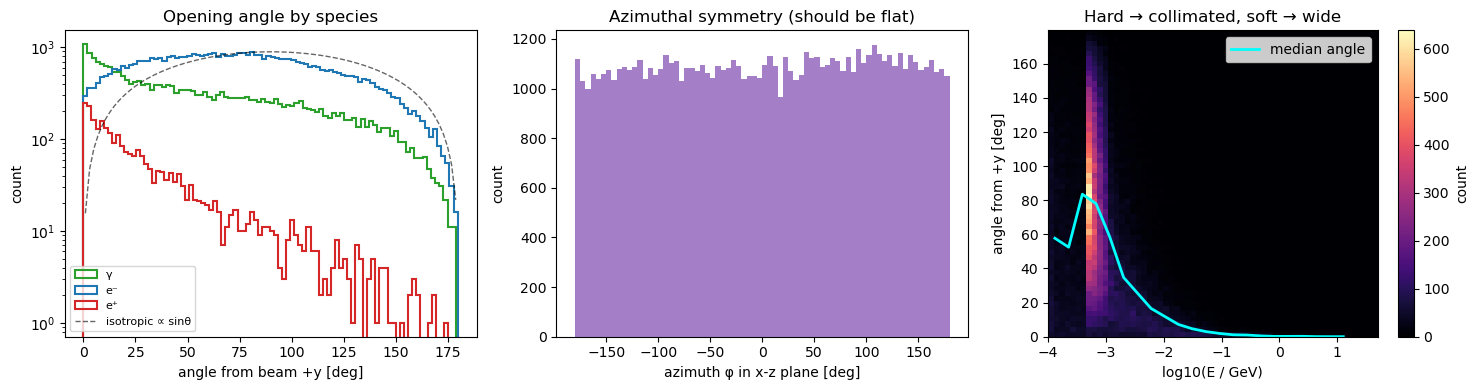

median opening angle: all = 64.7°, E>1 GeV = 0.08°, E<10 MeV = 67.5°
  e-    median = 73.4°, within 10deg =   4%, backward(>90deg) =  36%
  e+    median = 17.0°, within 10deg =  35%, backward(>90deg) =   6%
  gamma median = 48.6°, within 10deg =  17%, backward(>90deg) =  26%


In [16]:
pmag = np.sqrt(px**2 + py**2 + pz**2)
good = (pmag > 0) & em
theta = np.degrees(np.arccos(np.clip(py[good] / pmag[good], -1, 1)))   # angle from +y beam
phi   = np.degrees(np.arctan2(pz[good], px[good]))                     # azimuth in the x-z plane
Eg, gpdg = E[good], pdg[good]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# (a) opening angle, split by species, against an isotropic (sin theta) reference
for sel, lab, col in [(gpdg==22,"γ","#2ca02c"), (gpdg==11,"e⁻","#1f77b4"), (gpdg==-11,"e⁺","#d62728")]:
    ax[0].hist(theta[sel], bins=90, histtype="step", lw=1.5, color=col, label=lab)
_cnt, _ed = np.histogram(theta[gpdg==11], bins=90); _tc = 0.5*(_ed[:-1]+_ed[1:])
_ref = np.sin(np.radians(_tc)); _ref *= _cnt.max()/_ref.max()
ax[0].plot(_tc, _ref, "k--", lw=1, alpha=0.6, label="isotropic ∝ sinθ")
ax[0].set_yscale("log"); ax[0].set_xlabel("angle from beam +y [deg]"); ax[0].set_ylabel("count")
ax[0].set_title("Opening angle by species"); ax[0].legend(fontsize=8)
# (b) azimuthal symmetry (should be flat)
ax[1].hist(phi, bins=72, color="#9467bd", alpha=0.85)
ax[1].set_xlabel("azimuth φ in x-z plane [deg]"); ax[1].set_ylabel("count"); ax[1].set_ylim(bottom=0)
ax[1].set_title("Azimuthal symmetry (should be flat)")
# (c) collimation vs energy, with a median profile
le = np.log10(np.clip(Eg, 1e-4, None))
h = ax[2].hist2d(le, theta, bins=[60, 60], cmap="magma")
xb = np.linspace(le.min(), le.max(), 25); xc = 0.5*(xb[:-1]+xb[1:])
med = [np.median(theta[(le>=lo)&(le<hi)]) if ((le>=lo)&(le<hi)).any() else np.nan for lo, hi in zip(xb[:-1], xb[1:])]
ax[2].plot(xc, med, color="cyan", lw=2, label="median angle")
ax[2].set_xlabel("log10(E / GeV)"); ax[2].set_ylabel("angle from +y [deg]")
ax[2].set_title("Hard → collimated, soft → wide"); ax[2].legend()
plt.colorbar(h[3], ax=ax[2], label="count")
plt.tight_layout(); plt.show()
print(f"median opening angle: all = {np.median(theta):.1f}°, "
      f"E>1 GeV = {np.median(theta[Eg>1]):.2f}°, E<10 MeV = {np.median(theta[Eg<0.01]):.1f}°")
for code, lab in [(11, "e-"), (-11, "e+"), (22, "gamma")]:
    t = theta[gpdg == code]
    print(f"  {lab:5s} median = {np.median(t):4.1f}°, within 10deg = {np.mean(t<10):4.0%}, backward(>90deg) = {np.mean(t>90):4.0%}")

### Validating the truth — are the 4-vectors and vertices self-consistent?

**First, a key conceptual point.** One might expect a particle to travel in a straight line
from birth to death at constant energy — but that is not what the two vertices describe. The
*production* and *end* vertex bracket a particle's **entire trajectory**, not one straight
step. Between them the particle traverses its full range: a charged particle continuously
**loses energy** (ionisation + bremsstrahlung) *and* **changes direction** (multiple Coulomb
scattering) the whole way, while a neutral photon travels straight at constant energy *between*
interactions but is kinked by any Compton scatter. So the start→end segment is generally
neither straight nor energy-conserving, and the deviations below are physics, not artefacts.
Four cross-checks:

1. **Masses** match the PDG values (e± = 0.511 MeV, γ = 0).
2. **Energy conservation** at the first vertex — the primary photon's energy is shared by the
   e⁺e⁻ it pair-produces.
3. **Displacement vs momentum** — the start→end vector vs the *production* momentum. Photons
   are mostly perfectly aligned (straight); the tails are particles that got deflected.
4. **Energy loss** — the end momentum never exceeds the start. In fact almost *every* particle
   ends at rest (p_end ≈ 0): the soft cascade fully thermalises.

MASS CHECK [GeV]:
  e-: 0.000511   e+: 0.000511   gamma: 0.000000   (PDG: 0.000511, 0.000511, 0)

PRIMARY: pdg=22, E=50.00 GeV, converts at (0.0,1295.3,0.0) mm
products born there: 2 particle(s), pdg=[-11, 11], E = 47.59 + 2.41 = 50.00 GeV  (= primary 50.00 GeV)
  isolation check - particles within 1 µm / 10 µm / 100 µm of the conversion point: 2 / 2 / 2


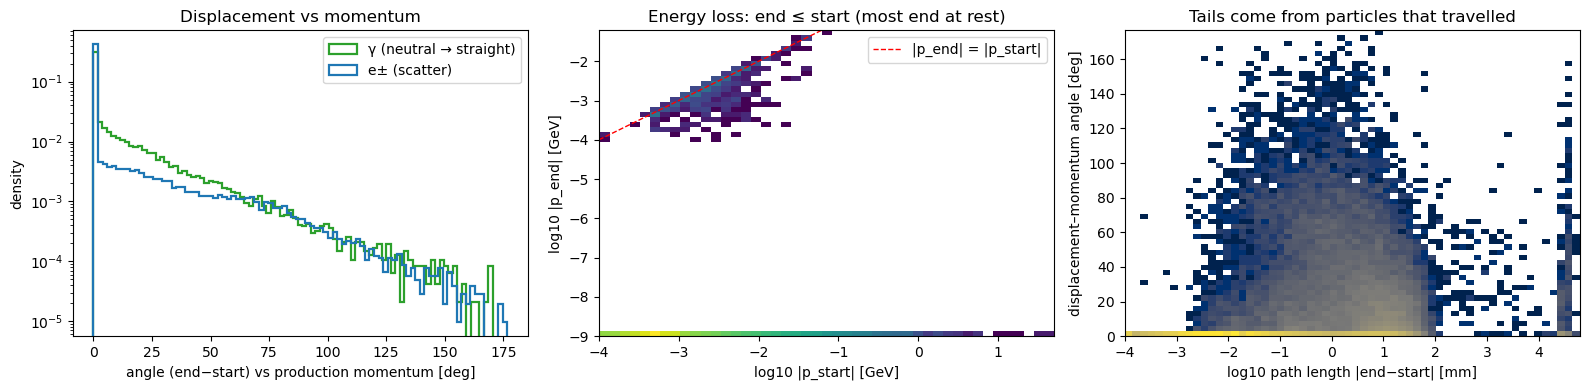

fraction with |p_end| <= |p_start|: 100.0%;  fraction ending at rest (p_end<1e-4 GeV): 99.3%
photons ending at p≈0 (converted/absorbed): 24,356 / 24,914


In [17]:
# 1) masses vs PDG
mm = lambda s: float(mass[s].mean()) if s.any() else float("nan")
print("MASS CHECK [GeV]:")
print(f"  e-: {mm(pdg==11):.6f}   e+: {mm(pdg==-11):.6f}   gamma: {mm(pdg==22):.6f}   (PDG: 0.000511, 0.000511, 0)")

# 2) first-vertex energy conservation. Pair-production products share the photon's conversion
#    point *exactly* (same Geant4 step point), so a 1 µm tolerance isolates them from the
#    downstream secondaries (born further along, once the e± have travelled a finite distance).
def _within(tol):
    return (np.abs(vsx-vex[0]) < tol) & (np.abs(vsy-vey[0]) < tol) & (np.abs(vsz-vez[0]) < tol)
conv = np.where(_within(1e-3))[0]
conv = conv[conv != 0]   # exclude the primary itself (it ends far from where it started)
print(f"\nPRIMARY: pdg={pdg[0]}, E={E[0]:.2f} GeV, converts at ({vex[0]:.1f},{vey[0]:.1f},{vez[0]:.1f}) mm")
print(f"products born there: {len(conv)} particle(s), pdg={sorted(set(int(pdg[i]) for i in conv))}, "
      f"E = {' + '.join(f'{E[i]:.2f}' for i in conv)} = {E[conv].sum():.2f} GeV  (= primary {E[0]:.2f} GeV)")
print(f"  isolation check - particles within 1 µm / 10 µm / 100 µm of the conversion point: "
      f"{int(_within(1e-3).sum())} / {int(_within(1e-2).sum())} / {int(_within(1e-1).sum())}")

# 3) displacement vs momentum, and 4) energy loss
disp = np.stack([vex-vsx, vey-vsy, vez-vsz], axis=1); dlen = np.linalg.norm(disp, axis=1)
pvec = np.stack([px, py, pz], axis=1);                pm   = np.linalg.norm(pvec, axis=1)
ok = (dlen > 1e-6) & (pm > 1e-9)
ang = np.degrees(np.arccos(np.clip(np.einsum("ij,ij->i", disp[ok], pvec[ok]) / (dlen[ok]*pm[ok]), -1, 1)))
okp = pdg[ok]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
# (a) displacement vs PRODUCTION momentum, by species
for sel, lab, col in [(okp==22,"γ (neutral → straight)","#2ca02c"), ((okp==11)|(okp==-11),"e± (scatter)","#1f77b4")]:
    if sel.any():
        ax[0].hist(ang[sel], bins=90, histtype="step", lw=1.6, color=col, label=lab, density=True)
ax[0].set_yscale("log"); ax[0].set_xlabel("angle (end−start) vs production momentum [deg]")
ax[0].set_ylabel("density"); ax[0].set_title("Displacement vs momentum"); ax[0].legend()

# (b) energy loss: end vs start momentum -- nearly everything ends at rest
pend = np.sqrt(pex**2 + pey**2 + pez**2); s = pm > 0
ax[1].hist2d(np.log10(np.clip(pm[s],1e-6,None)), np.log10(np.clip(pend[s],1e-9,None)),
             bins=[60,60], cmap="viridis", norm=plt.matplotlib.colors.LogNorm())
lim = [-4, np.log10(pm.max())]
ax[1].plot(lim, lim, "r--", lw=1, label="|p_end| = |p_start|")
ax[1].set_xlim(lim); ax[1].set_ylim(bottom=-9)
ax[1].set_xlabel("log10 |p_start| [GeV]"); ax[1].set_ylabel("log10 |p_end| [GeV]")
ax[1].set_title("Energy loss: end ≤ start (most end at rest)"); ax[1].legend()
ax[1].annotate("bottom row = stopped (p_end ≈ 0)", xy=(0.5, 0.03), xycoords="axes fraction",
               ha="center", fontsize=7, color="white")

# (c) WHY the tails -- the deflected particles are the ones that TRAVELLED far
ax[2].hist2d(np.log10(np.clip(dlen[ok], 1e-4, None)), ang, bins=[60, 60],
             cmap="cividis", norm=plt.matplotlib.colors.LogNorm())
ax[2].set_xlabel("log10 path length |end−start| [mm]"); ax[2].set_ylabel("displacement–momentum angle [deg]")
ax[2].set_title("Tails come from particles that travelled")
plt.tight_layout(); plt.show()
print(f"fraction with |p_end| <= |p_start|: {(pend <= pm + 1e-6).mean():.1%};  "
      f"fraction ending at rest (p_end<1e-4 GeV): {(pend < 1e-4).mean():.1%}")
print(f"photons ending at p≈0 (converted/absorbed): {int(((pdg==22)&(pend<1e-4)).sum()):,} / {int((pdg==22).sum()):,}")

**Reading the panels.** *Left:* photons (green) pile up at angle ≈ 0 — straight until a
discrete interaction — while the electron distribution has a long tail to large angles.
*Middle:* the dense **bottom row** is the ~99% of tracks that end at rest (p_end ≈ 0); the
cascade fully thermalises, so essentially everything loses ~100% of its momentum and "momentum
change" *cannot by itself* explain the angular tails. The red diagonal is the |p_end| = |p_start|
ceiling, which nothing crosses. *Right:* here the dense **bottom row** is the majority that go
essentially straight (displacement angle ≈ 0) — they stop before travelling far, or are neutral
photons. The angle only grows with **path length**: large-angle electrons travelled ~90× farther
than the straight ones (more distance ⇒ more accumulated multiple scattering), and large-angle
photons ~3× farther (they Compton-scattered, then continued). So the tails *are* the "affected"
particles — picked out by distance travelled, not by momentum lost.

### The cascade tree — who made whom

Using the parent→daughter links (extracted from the EDM4hep `daughters` relation) we can draw
the actual **cascade tree**, not a set of disconnected tracks. Starting from the primary photon
we follow its hardest descendants, so every drawn track's parent is also drawn: the segments
**branch at the vertices** where new particles are created, and the electron → photon →
electron alternation of an electromagnetic shower becomes visible. Each segment runs from a
particle's production vertex to its end point, coloured by species. We keep the hardest ~120
*connected* e±/γ — the visible skeleton, with the soft sea omitted — and clip the incoming
photon to the ECal front (y = 1264 mm). **Left:** the shower *in space* (depth vs transverse),
each track shaded and weighted by energy, with the production vertices marked. **Right:** an
abstract **genealogy** — generation from the primary on the x-axis, one node per particle,
edges from parent to child — which makes the branching and the brem photons easy to follow even
where they overlap in space.

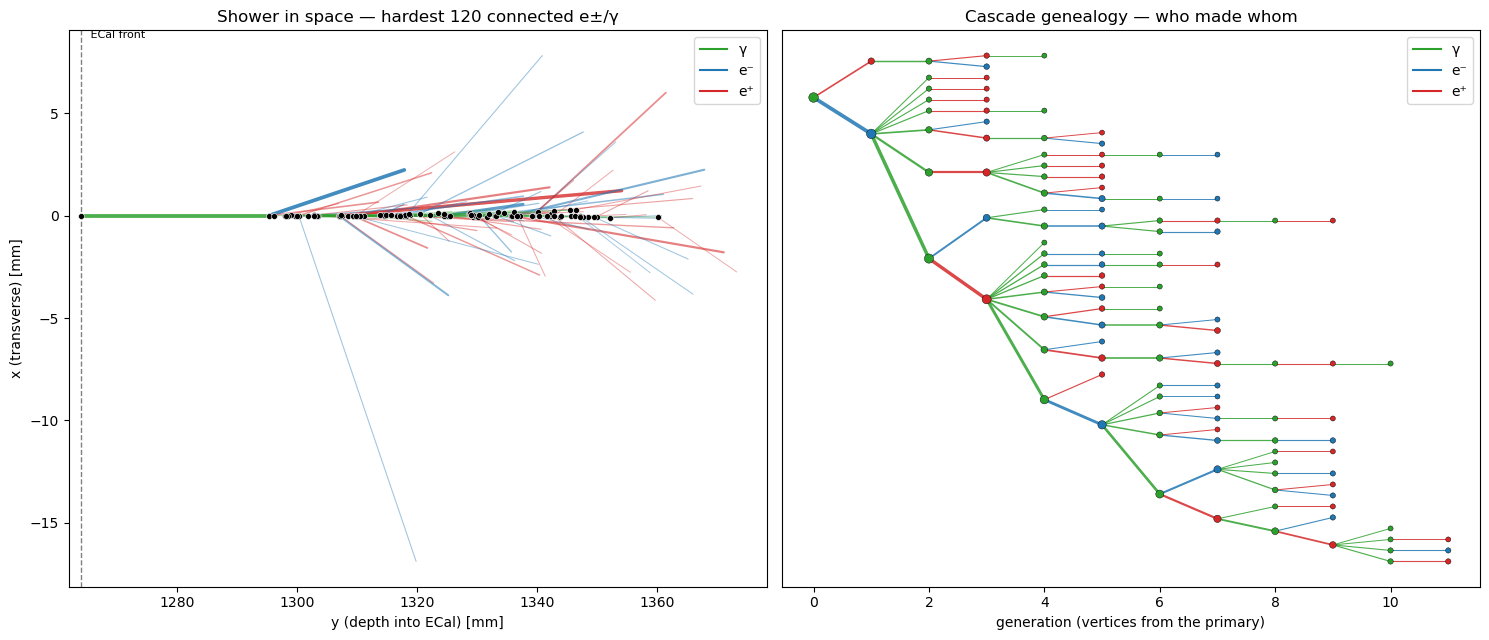

tree: 120 connected nodes — 64 e± + 56 γ; root = primary photon (50 GeV); max generation = 11
branching example — the primary's daughters: [(11, 47.59), (-11, 2.41)] GeV
edge processes (parent → child): γ→e⁺=35, γ→e⁻=29, e⁺→γ=29, e⁻→γ=26


In [18]:
import heapq
# dbeg/dend/dau already bound in the array-pull cell above
children = lambda i: [int(c) for c in dau[dbeg[i]:dend[i]]]

# Grow a CONNECTED tree from the primary (index 0): expand into the highest-energy reachable
# e±/γ daughter until N nodes, recording each node's parent so we can draw the genealogy.
N = 120
keep, seen, parent, heap = [], set(), {0: None}, [(-float(E[0]), 0)]
while heap and len(keep) < N:
    negE, i = heapq.heappop(heap)
    if i in seen:
        continue
    seen.add(i); keep.append(i)
    for c in children(i):
        if c not in seen and int(pdg[c]) in (22, 11, -11):
            parent.setdefault(c, i)
            heapq.heappush(heap, (-float(E[c]), c))
keepset = set(keep)

cmap = {22: "#2ca02c", 11: "#1f77b4", -11: "#d62728"}; pcol = lambda p: cmap[int(p)]
lw   = lambda e: 0.5 + 1.3*np.log10(max(e, 1e-3) + 1)
alph = lambda e: float(np.clip(0.35 + 0.5*np.log10(max(e, 1e-3) + 1)/np.log10(51), 0.35, 0.95))
zo   = lambda p: 3 if int(p) == 22 else 2          # draw photons over e+- so they stay visible
cy   = lambda v: max(float(v), 1264.0)             # clip the incoming primary photon to the ECal front
from matplotlib.lines import Line2D
legend = [Line2D([0],[0],color=c,label=l) for l,c in [("γ","#2ca02c"),("e⁻","#1f77b4"),("e⁺","#d62728")]]

fig = plt.figure(figsize=(15, 6.5))
# --- left: the shower in space (depth vs transverse) ---
ax2 = fig.add_subplot(1, 2, 1)
for i in keep:
    ax2.plot([cy(vsy[i]), vey[i]], [vsx[i], vex[i]], color=pcol(pdg[i]), lw=lw(E[i]),
             alpha=alph(E[i]), solid_capstyle="round", zorder=zo(pdg[i]))
ax2.scatter([cy(vsy[i]) for i in keep], [vsx[i] for i in keep], s=18, color="k",
            edgecolor="w", linewidth=0.4, zorder=5)
ax2.axvline(1264, ls="--", color="grey", lw=1); ax2.text(1265, ax2.get_ylim()[1], " ECal front", fontsize=8, va="top")
ax2.set_xlim(1262, max(vey[i] for i in keep) + 5)
ax2.set_xlabel("y (depth into ECal) [mm]"); ax2.set_ylabel("x (transverse) [mm]")
ax2.set_title(f"Shower in space — hardest {len(keep)} connected e±/γ"); ax2.legend(handles=legend, loc="upper right")

# --- right: genealogy tree-graph (generation x layout); photons become distinct nodes ---
ax3 = fig.add_subplot(1, 2, 2)
kids = {i: [] for i in keep}
for c in keep:
    if parent.get(c) in keepset: kids[parent[c]].append(c)
gen = {}
def _gen(i):
    if i not in gen:
        p = parent.get(i); gen[i] = 0 if (p is None or p not in keepset) else _gen(p) + 1
    return gen[i]
for i in keep: _gen(i)
ypos, ctr = {}, [0]
def _layout(i):
    ks = sorted(kids[i], key=lambda c: -E[c])
    if not ks:
        ypos[i] = ctr[0]; ctr[0] += 1
    else:
        for c in ks: _layout(c)
        ypos[i] = float(np.mean([ypos[c] for c in ks]))
for r in [i for i in keep if parent.get(i) not in keepset]: _layout(r)
for c in keep:
    if parent.get(c) in keepset:
        ax3.plot([gen[parent[c]], gen[c]], [ypos[parent[c]], ypos[c]],
                 color=pcol(pdg[c]), lw=lw(E[c]), alpha=0.85, zorder=zo(pdg[c]))
ax3.scatter([gen[i] for i in keep], [ypos[i] for i in keep], c=[pcol(pdg[i]) for i in keep],
            s=[10 + 22*np.log10(max(E[i], 1e-3) + 1) for i in keep], edgecolor="k", linewidth=0.3, zorder=5)
ax3.set_xlabel("generation (vertices from the primary)"); ax3.set_yticks([])
ax3.set_title("Cascade genealogy — who made whom"); ax3.legend(handles=legend, loc="upper right")
plt.tight_layout(); plt.show()

n_g = sum(1 for i in keep if pdg[i] == 22); n_em = len(keep) - n_g
print(f"tree: {len(keep)} connected nodes — {n_em} e± + {n_g} γ; root = primary photon ({E[0]:.0f} GeV); "
      f"max generation = {max(gen.values())}")
print(f"branching example — the primary's daughters: {[(int(pdg[c]), round(float(E[c]),2)) for c in children(0)]} GeV")
import collections as _coll
_t = _coll.Counter((int(pdg[parent[c]]), int(pdg[c])) for c in keep if parent.get(c) in keepset)
_nm = {22: "γ", 11: "e⁻", -11: "e⁺"}
print("edge processes (parent → child): " + ", ".join(f"{_nm[a]}→{_nm[b]}={n}" for (a, b), n in sorted(_t.items(), key=lambda x: -x[1])))

**Reading the genealogy — an edge means *produced*, not *became*.** A particle keeps going
after it spawns a child; only pair production and annihilation actually *consume* the parent.
Two processes drive the cascade, and the printed edge counts show both directions in roughly
equal measure:
- **γ → e⁺e⁻** (pair production): a photon converts into an electron–positron pair and is gone.
- **e± → γ** (bremsstrahlung) — plus **e⁺ → γγ** annihilation at the end of a positron's range:
  a charged particle radiates photons *at many successive points along its track* while
  continuing on. That is why one hard e± fathers a whole fan of photons (the 47.6 GeV electron
  here emits dozens of bremsstrahlung photons before it stops; a stopping positron ends by
  annihilating into two 0.511 MeV photons).

So "a positron turning into photons" is really *radiate-along-the-track, then annihilate*, and
"an electron into many photons" is *bremsstrahlung at many vertices*. Those emission points are
real, **distinct vertices spread along each track** — visible as the black dots strung along the
tracks in the left (spatial) panel. The genealogy collapses them onto one node per particle to
show the lineage cleanly; the spatial panel is where their positions live.

> **The two-readout cross-check lives in [06 §8](06_sensor_crossings_tracker.ipynb):** that the
> calorimeter and tracker readouts are byte-identically the *same* seed-424242 shower. This
> notebook anchors its own absolute scale in §9 (the deposits are a silicon MIP; the crossing
> count traces the energy profile), and restores the full particle cascade in §10.

## Summary

- **The per-sensor crossing product is produced programmatically** from the simulation:
  `enableDetailedShowerMode` surfaces the Geant4 step truth on the EDM4hep path, and
  `analysis/sensor_crossings.py` (`build_segments_A`) reshapes it into **2,535 charged-track
  crossings** for this 50 GeV event — each with a local impact point, `cot α`/`cot β`, `|p|`
  and particle type.
- **The reconstruction choices are validated against the data:** the +y face at 90°, layers
  labelled by depth (not radius — radius mislabels off-axis steps by up to 12 mm, depth keeps
  every step in the right sensor), time-ordered entry/direction (correct for inward and
  outward tracks), and the expected hard-perpendicular / soft-wide angular behaviour.
- The same records can be serialized to `.json`/`.csv` with
  `sensor_crossings.write_intermediate` (notebook 06 §7 does exactly that for the tracker
  route, and documents the field-by-field schema).

**Known limitation of this calorimeter route:** the EDM4hep `CaloHitContribution` carries no
per-step momentum, so each crossing inherits the producing particle's **production** momentum
(fine for the hard, near-straight tracks that dominate; wrong for a particle that has radiated
down to low energy by a deep layer). The companion route —
[06](06_sensor_crossings_tracker.ipynb), the tracker readout — resolves this with the true
per-crossing momentum, which is why it is the primary. This is a single 50 GeV event;
`build_segments_A()` itself is event-agnostic, but the shipped extractor CLIs process one
event per `.npz` (`extract_cascade.py` takes an event index), so a multi-event campaign loops
sim → extract → convert per event.

For collaborators who want ready-to-run inputs for **PIXELAV** (the silicon charge-transport
simulation these records were commissioned for): the `pixelav-inputs` branch of this
repository converts the crossing records into PIXELAV's input-deck format and documents the
conventions.
